In [1]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
import pandas as pd
from rubin_sim.maf import radar
import os

from matplotlib.legend_handler import HandlerErrorbar


In [2]:
def norm_df(
    df,
    runs,
    cols,
    norm_run="baseline",
    invert_cols=None,
    reverse_cols=None,
    run_label="run_name",
    mag_cols=[],
):
    """
    Normalize values in a dataframe to a given run
    Parameters
    ----------
    df : pandas.DataFrame
        The input data frame
    runs : list of str
        A list of run numes
    cols : list of str
        A list of columns in df to use
    norm_run : str
        The row to use to normalize things to
    invert_cols : list of str
        A list of column names that should be inverted (e.g., columns that
        are uncertainties and are better with a smaller value)
    reverse_cols : list of str
        Columns to reverse (e.g., magnitudes)
    run_label : str (run_name)
        The column that has run names
    mag_cols : list of str
        Columns that are in magnitudes
    """
    indices = [np.max(np.where(df.index == name)[0]) for name in runs]
    out_df = df[cols].iloc[indices].copy()
    if reverse_cols is not None:
        for colname in reverse_cols:
            out_df[colname] = -out_df[colname]
    if invert_cols is not None:
        for colname in invert_cols:
            out_df[colname] = 1.0 / out_df[colname]
    if norm_run is not None:
        indx = np.max(np.where(out_df.index == norm_run)[0])
        for col in out_df.columns:
            # maybe just check that it's not a
            if col != "run_name":
                if (col in mag_cols) | (mag_cols == "all"):
                    out_df[col] = 1.0 + (out_df[col] - out_df[col].iloc[indx])
                else:
                    out_df[col] = (
                        1.0
                        + (out_df[col] - out_df[col].iloc[indx])
                        / out_df[col].iloc[indx]
                    )
    return out_df

In [3]:
data_loaded = pd.read_hdf('summary.h5')
data_loaded.shape


(93, 256971)

In [4]:
indx = np.isfinite(data_loaded["best18k Parallax fiveSigmaDepth, band, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"].values)
data_loaded.loc[indx, ["best18k Parallax fiveSigmaDepth, filter, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"]] = data_loaded["best18k Parallax fiveSigmaDepth, band, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"].iloc[indx]

#for bandname in 'ugrizy':
#    indx = np.isfinite(data_loaded["Median CoaddM5 band%s HealpixSlicer" % bandname].values)
#    d1 = data_loaded["Median CoaddM5 %s HealpixSlicer" % bandname].values
#    d1[indx] = data_loaded["Median CoaddM5 band%s HealpixSlicer" % bandname].iloc[indx].values
#    data_loaded["Median CoaddM5 %s HealpixSlicer" % bandname] = d1

In [5]:
# Pull out the metrics we are interested in and define simple names

name_dict = {'FootprintFraction N year 1 u and night < 365 HealpixSlicer': 'Y1,u',
            'FootprintFraction N year 1 g and night < 365 HealpixSlicer': 'Y1,g',
            'FootprintFraction N year 1 r and night < 365 HealpixSlicer': 'Y1,r',

            'FootprintFraction N year 1 i and night < 365 HealpixSlicer': 'Y1,i',
    'best18k Parallax fiveSigmaDepth, filter, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer': 'parallax best 18k',
            'best18k properMotion HealpixSlicer': 'proper motion best 18k',
            'Fraction detected of total (mean) MicrolensingMetric_detect tE 20_30 days UserPointsSlicer': '20-30d microlensing\ndetection',
            'Fraction detected of total (mean) MicrolensingMetric_detect tE 60_90 days UserPointsSlicer': '60-90d microlensing\ndetection',
            'fONv MedianNvis fO HealpixSlicer': 'fO N vis',
             #'fOArea_750 fO All sky HealpixSlicer': 'fO Area 750',
            'Total detected SNNSNMetric_reducen_sn DDF excluded HealpixSlicer': 'SNe, N',
             'Median SNNSNMetric_reducezlim DDF excluded HealpixSlicer': 'SNe, zlim',
            '3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer': '3x2 i-band',
            'Median WeakLensingNvisits gri band non-DD HealpixSlicer': 'WL Nvis \ni-band',
            'Total detected KNePopMetric_all_ztfrest_simple all models UserPointsSlicer': 'KNe ZTF simple',
            'Total detected KNePopMetric_single_ztfrest_simple single model UserPointsSlicer': 'KNe single model',
            #'Sum PrestoKNe_score_p UserPointsSlicer': 'KNe Score, P',
            'Sum ColorSlope visitExposureTime > 19 HealpixSlicer': 'color slope',
            "Sum ColorSlope2Night visitExposureTime > 19 HealpixSlicer": "2day\ncolor slope",
            'Total detected XRBPopMetric_early_detect UserPointsSlicer': 'XRB\nearly detect',
            'VolumeSum Brown Dwarf, L7 HealpixSlicer': 'Brown Dwarf Vol',
            'CumulativeCompleteness H <= 16.000000 DiscoveryNChances NEO 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'NEO bright',
            'CumulativeCompleteness H <= 22.000000 DiscoveryNChances NEO 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'NEO faint',
            'CumulativeCompleteness H <= 6.000000 DiscoveryNChances TNO 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'TNO',
            'CumulativeCompleteness H <= 20.000000 DiscoveryNChances MBA 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'MBA',
            'CumulativeCompleteness H <= 18.000000 DiscoveryNChances Trojan 3 pairs in 15 nights SNR=3 detection loss MoObjSlicer': 'Trojan',
            'CumulativeCompleteness H <= 16.000000 DiscoveryNChances Vatira 1 quad in 1 night detection loss MoObjSlicer': 'Vatira',
             'FractionPop Lightcurve Inversion H = 18.000000 LightcurveInversionAsteroid MBA MoObjSlicer': 'MBA, LCI',
            # 'CumulativeCompleteness H <= 16.000000 DiscoveryNChances Vatira 3 pairs in 15 nights SNR=5 detection loss MoObjSlicer': 'Vatira 3pairs, 15days, snr=5',
            #'CumulativeCompleteness H <= 20.000000 DiscoveryNChances PHA 1 quad in 1 night detection loss MoObjSlicer': 'PHA, quad',
            #'Fraction detected of total (mean) KNePopMetric_single_multi_color_detect single model UserPointsSlicer': "KNe\n multi-color"
            }
            
# drop in the units for the columns
units = {'parallax best 18k': 'mas',
         'proper motion best 18k': 'mas/yr',
         '20-30d microlensing\ndetection': 'fraction', 
         '60-90d microlensing\ndetection': 'fraction', 
         'fO N vis' : '', 
         'fO Area 750': '',
         'SNe, N': '', 
         'SNe, zlim': '', 
         '3x2 i-band': 'score', 
         'WL Nvis \ni-band': '', 
         'KNe ZTF simple': 'N', 
         'KNe single model': 'N',
         'KNe Score, P': 'score',
         'XRB\nearly detect': 'N', 
         'Brown Dwarf Vol': 'pc^3', 
         'NEO bright': 'fraction', 
         'NEO faint': 'fraction', 
         'TNO': 'fraction', 
         'MBA':'fraction',
         'Trojan': 'fraction',
         "MBA, LCI": "fraction",
         'Vatira': 'fraction',
         'Vatira 3pairs, 15days, snr=5': "fraction",
         'PHA, quad': 'fraction',
         'Y1,u': '',
         'Y1,g': '',
         'Y1,r': '',
         'Y1,i': '',
         'color slope': 'N',
         '2day\ncolor slope': 'N',
         "KNe\n multi-color": "fraction",
        }

# If columns are uncertainties, we want to plot them backwards
invert_cols = ['parallax best 18k', 'proper motion best 18k']
# If columns are mags or fractions, we want to plot differences, not fractional differences.
mag_cols = ['20-30d microlensing\ndetection', '60-90d microlensing\ndetection','SNe, zlim',
            'NEO bright', 'NEO faint', 'TNO', 'Vatira', 'MBA', 'Trojan',
           'u', 'g', 'r', 'i', 'z', 'y']

data = pd.DataFrame()
for key in name_dict:
    data[name_dict[key]] = data_loaded[key]
    

mag_dict = {'Median CoaddM5 g HealpixSlicer': 'g',
 'Median CoaddM5 i HealpixSlicer': 'i',
 'Median CoaddM5 r HealpixSlicer': 'r',
 'Median CoaddM5 u HealpixSlicer': 'u',
 'Median CoaddM5 y HealpixSlicer': 'y',
 'Median CoaddM5 z HealpixSlicer': 'z'}

mag_data = pd.DataFrame()
for key in mag_dict:
    mag_data[mag_dict[key]] = data_loaded[key]
    
    
    
ddf_dict = {'Sum SNNSNMetric DD:COSMOS_reducen_sn DD:COSMOS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN COSMOS',
           'Sum SNNSNMetric DD:ECDFS_reducen_sn DD:ECDFS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN ECDFS',
           'Sum SNNSNMetric DD:EDFS_reducen_sn DD:EDFS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN EDFS',
           'Sum SNNSNMetric DD:ELAISS1_reducen_sn DD:ELAISS1 all bands, only DDF observations HealpixSubsetSlicer' : 'N SN ELAISS1',
           'Sum SNNSNMetric DD:XMM_LSS_reducen_sn DD:XMM_LSS all bands, only DDF observations HealpixSubsetSlicer' : 'N SN XMM_LSS',
            
           'Median SNNSNMetric DD:COSMOS_reducezlim DD:COSMOS all bands, only DDF observations HealpixSubsetSlicer': 'zlim COSMOS',
            'Median SNNSNMetric DD:ECDFS_reducezlim DD:ECDFS all bands, only DDF observations HealpixSubsetSlicer': 'zlim ECDFS',
            'Median SNNSNMetric DD:EDFS_reducezlim DD:EDFS all bands, only DDF observations HealpixSubsetSlicer': 'zlim EDFS',
            'Median SNNSNMetric DD:ELAISS1_reducezlim DD:ELAISS1 all bands, only DDF observations HealpixSubsetSlicer': 'zlim ELAISS1',
            'Median SNNSNMetric DD:XMM_LSS_reducezlim DD:XMM_LSS all bands, only DDF observations HealpixSubsetSlicer': 'zlim XMM_LSS',
            
           'Total detected KNePopMetric_DD:COSMOS_ztfrest_simple DD:COSMOS UserPointsSlicer': 'Kne COSMOS',
         'Total detected KNePopMetric_DD:ECDFS_ztfrest_simple DD:ECDFS UserPointsSlicer': 'Kne ECDFS',
 'Total detected KNePopMetric_DD:EDFS_ztfrest_simple DD:EDFS UserPointsSlicer': 'Kne EDFS',
 'Total detected KNePopMetric_DD:ELAISS1_ztfrest_simple DD:ELAISS1 UserPointsSlicer': 'Kne ELAISS1',
 'Total detected KNePopMetric_DD:WFD_ztfrest_simple DD:WFD UserPointsSlicer': 'Kne WFD',
 'Total detected KNePopMetric_DD:XMM_LSS_ztfrest_simple DD:XMM_LSS UserPointsSlicer': 'Kne XMM_LSS',
            
            'Median DD:COSMOS NVisits all bands HealpixSubsetSlicer':'N COSMOS',
 'Median DD:ECDFS NVisits all bands HealpixSubsetSlicer': 'N ECDFS',
 'Median DD:EDFS NVisits all bands HealpixSubsetSlicer': 'N EDFS',
 'Median DD:ELAISS1 NVisits all bands HealpixSubsetSlicer': 'N ELAISS1',
 'Median DD:WFD NVisits all bands HealpixSubsetSlicer': 'N WFD',
 'Median DD:XMM_LSS NVisits all bands HealpixSubsetSlicer': 'N XMM_LSS', 
           }

ddf_data = pd.DataFrame()
for key in ddf_dict:
    ddf_data[ddf_dict[key]] = data_loaded[key]
 
gaps_dict = {}
for filtername in 'ugrizy':
    for times in [3,7,24]:
        gaps_dict['Mean N gaps in %s at %ihr in top 18k Gaps_%ihr %s band HealpixSlicer'% (filtername, times, times, filtername)] = 'gaps %s %i' % (filtername, times)
        #gaps_dict['Mean Gaps_%ihr %s band HealpixSlicer' % (times, filtername)] = 'gaps %s %i' % (filtername, times)
        
gaps_data = pd.DataFrame()
for key in gaps_dict:
    gaps_data[gaps_dict[key]] = data_loaded[key]

In [6]:
[col for col in data_loaded.columns if "Inver" in col and "MBA" in col and "H = 18.0" in col]


['FractionPop Lightcurve Inversion H = 18.000000 LightcurveInversionAsteroid MBA MoObjSlicer']

In [7]:
[col for col in data_loaded.columns if "greed" in col ]


['Identity Counts_greedy UniSlicer',
 'Identity Counts_greedy g UniSlicer',
 'Identity Counts_greedy i UniSlicer',
 'Identity Counts_greedy r UniSlicer',
 'Identity Counts_greedy u UniSlicer',
 'Identity Counts_greedy y UniSlicer',
 'Identity Counts_greedy z UniSlicer',
 'Identity Percents_greedy UniSlicer',
 'Identity Percents_greedy g UniSlicer',
 'Identity Percents_greedy i UniSlicer',
 'Identity Percents_greedy r UniSlicer',
 'Identity Percents_greedy u UniSlicer',
 'Identity Percents_greedy y UniSlicer',
 'Identity Percents_greedy z UniSlicer']

In [8]:
# [name for name in mag_data.index if "prod" in name]

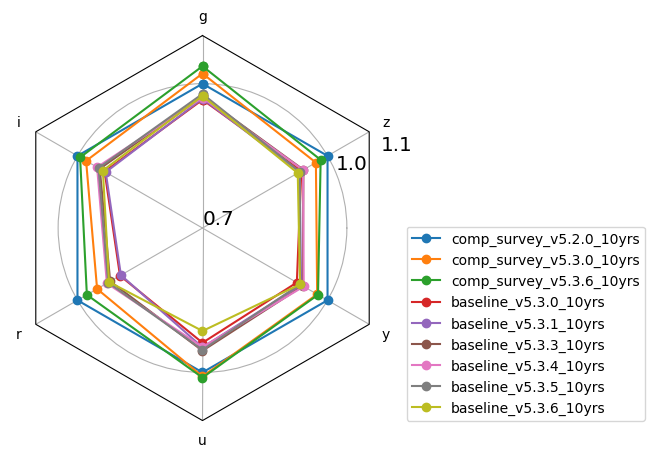

In [9]:
runs = ['comp_survey_v5.2.0_10yrs', 'comp_survey_v5.3.0_10yrs', 'comp_survey_v5.3.6_10yrs', 'baseline_v5.3.0_10yrs',
        'baseline_v5.3.1_10yrs','baseline_v5.3.3_10yrs','baseline_v5.3.4_10yrs',
       'baseline_v5.3.5_10yrs', 'baseline_v5.3.6_10yrs']
ndata = norm_df(mag_data, runs, cols=mag_data.columns.values.tolist(),
                 mag_cols = mag_cols, norm_run='comp_survey_v5.2.0_10yrs')#, invert_cols=['u', 'g', 'r', 'i', 'z', 'y'])
fig, ax = radar(ndata, legend=True, rgrids=[0.7, 1.0, 1.1], bbox_to_anchor=(1.65, 0))


In [10]:
mag_data.loc[runs]

,g,i,r,u,y,z
run_name,,,,,,
comp_survey_v5.2.0_10yrs,26.903095,26.401109,26.918030,25.573599,24.770187,25.731193
comp_survey_v5.3.0_10yrs,26.924164,26.380406,26.870938,25.581958,24.745296,25.703285
comp_survey_v5.3.6_10yrs,26.939449,26.394802,26.895493,25.584378,24.747319,25.714679
baseline_v5.3.0_10yrs,26.869829,26.335986,26.815958,25.511956,24.696524,25.668283
baseline_v5.3.1_10yrs,26.872114,26.333329,26.813787,25.521469,24.706717,25.664267
baseline_v5.3.3_10yrs,26.876795,26.347625,26.839551,25.528512,24.710845,25.673334
baseline_v5.3.4_10yrs,26.873946,26.353990,26.847473,25.520918,24.713047,25.672622
baseline_v5.3.5_10yrs,26.881802,26.350593,26.844467,25.526564,24.704219,25.664996
baseline_v5.3.6_10yrs,26.877666,26.340180,26.842230,25.487509,24.704187,25.659739


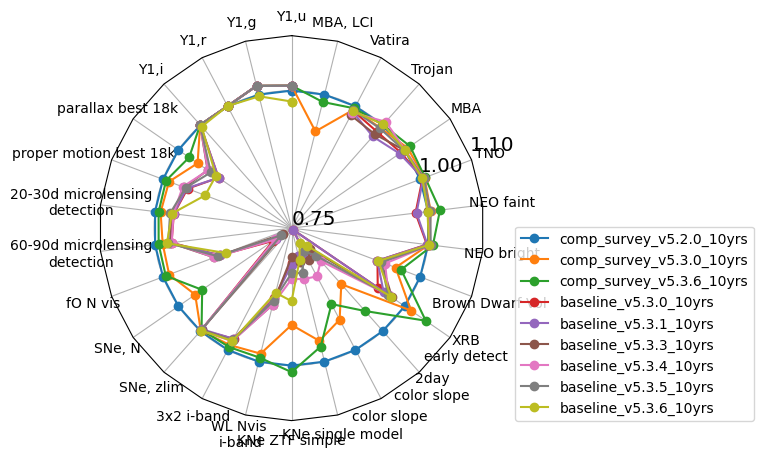

In [11]:
ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='comp_survey_v5.2.0_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.75, 1.0, 1.1], bbox_to_anchor=(1.7, 0))


In [12]:
ndata

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira,"MBA, LCI"
run_name,,,,,,,,,,,,,,,,,,,,,
comp_survey_v5.2.0_10yrs,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.0000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000
comp_survey_v5.3.0_10yrs,1.009010,1.016200,1.000618,1.000742,0.957641,0.988306,0.9899,0.9861,0.988048,0.962958,...,0.886224,1.013776,0.952178,1.0014,1.004710,1.008585,1.006373,0.993392,0.9935,0.931129
comp_survey_v5.3.6_10yrs,1.009151,1.016451,1.000494,1.000742,0.976295,0.994052,0.9936,0.9935,0.994688,0.947530,...,0.951344,1.046429,0.962988,1.0088,1.021830,1.009584,1.011830,1.000655,0.9959,0.986226
baseline_v5.3.0_10yrs,1.008588,1.016200,1.000618,1.000494,0.911338,0.952293,0.9656,0.9699,0.889774,0.790660,...,0.754245,0.940306,0.917021,0.9978,0.976998,1.004627,0.991552,0.984138,0.9910,0.647383
baseline_v5.3.1_10yrs,1.008588,1.016200,1.000618,1.000494,0.911279,0.953969,0.9661,0.9724,0.889774,0.784099,...,0.754001,0.953061,0.916879,0.9988,0.978841,1.005889,0.988584,0.972613,0.9891,0.619835
baseline_v5.3.3_10yrs,1.008588,1.016451,1.000494,1.000618,0.935520,0.958362,0.9690,0.9722,0.900398,0.768022,...,0.799606,0.971939,0.924373,1.0014,1.000695,1.007670,0.999268,0.978115,0.9818,0.641873
baseline_v5.3.4_10yrs,1.008729,1.016200,1.000618,1.000494,0.934769,0.961759,0.9663,0.9695,0.900398,0.785763,...,0.829895,0.964286,0.931692,1.0034,1.002799,1.007426,1.000611,1.008246,0.9874,0.672176
baseline_v5.3.5_10yrs,1.008869,1.016200,1.000494,1.000742,0.928358,0.956228,0.9725,0.9760,0.893758,0.772913,...,0.817392,0.962755,0.924644,1.0048,1.004314,1.007003,0.998893,0.992119,0.9921,0.659780
baseline_v5.3.6_10yrs,0.980149,0.996860,1.000618,0.996539,0.917227,0.918052,0.9692,0.9783,0.877822,0.732121,...,0.792899,0.969388,0.918818,1.0016,0.998935,1.004558,0.999642,1.001916,0.9900,0.637741


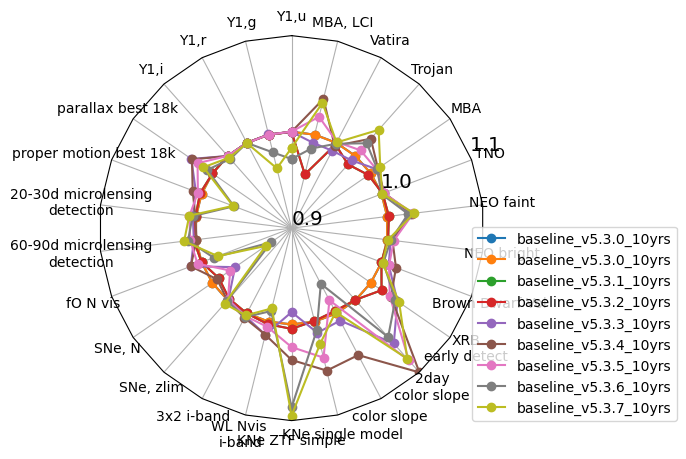

In [13]:
runs = ['baseline_v5.3.0_10yrs'] + [run for run in data_loaded.index if 'baseline_v5.3' in run and "10yrs" in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.0_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


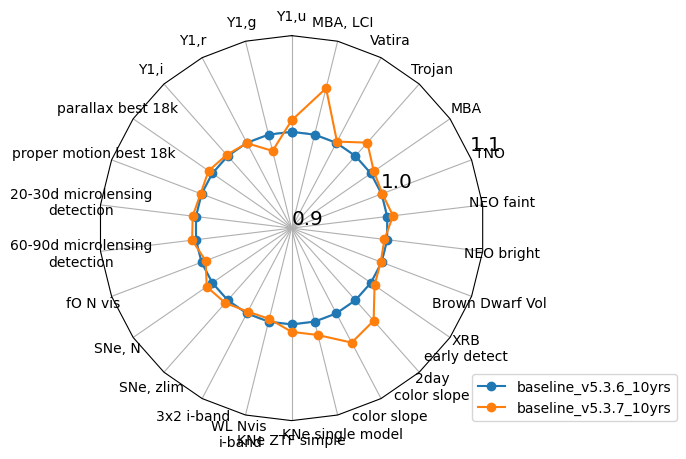

In [14]:
runs = ['baseline_v5.3.6_10yrs'] + ['baseline_v5.3.7_10yrs'] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.6_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


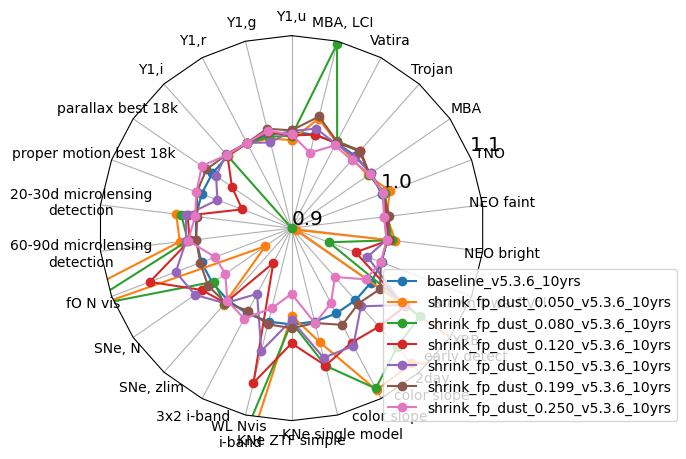

In [15]:
runs = ['baseline_v5.3.6_10yrs'] + [run for run in data_loaded.index if 'v5.3.6' in run and "shrink" in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.6_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


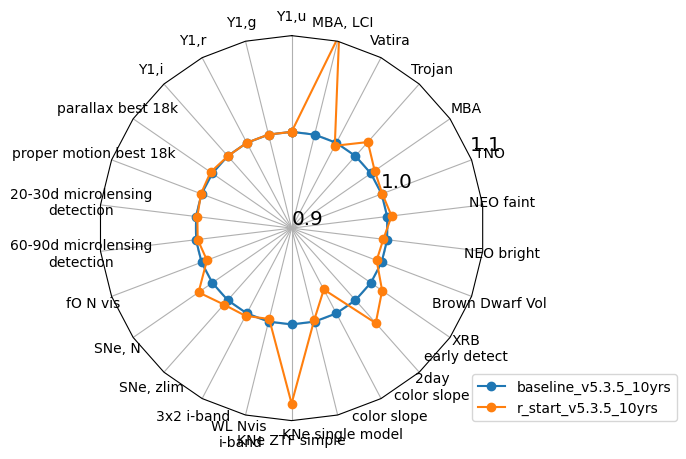

In [16]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'v5.3.5' in run and "r_start" in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


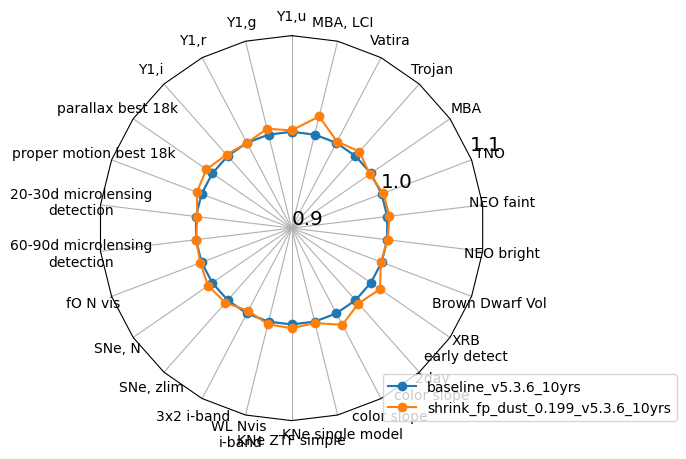

In [17]:
runs = ['baseline_v5.3.6_10yrs'] + [run for run in data_loaded.index if 'shrink' in run and '5.3.6' in run and '.199' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.6_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


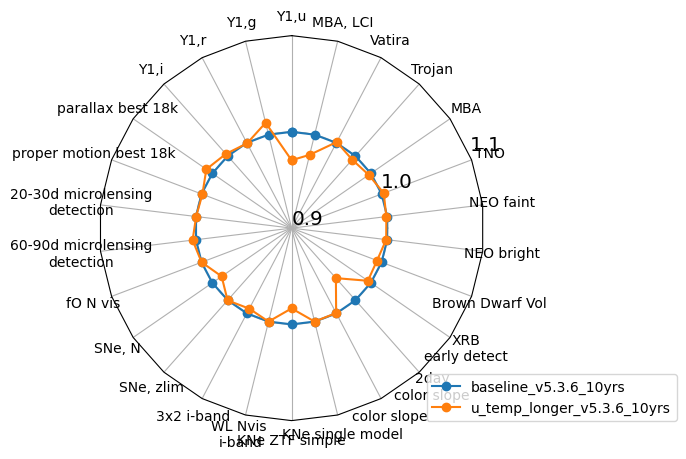

In [18]:
runs = ['baseline_v5.3.6_10yrs'] + [run for run in data_loaded.index if 'u_temp' in run and '5.3.6' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.6_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


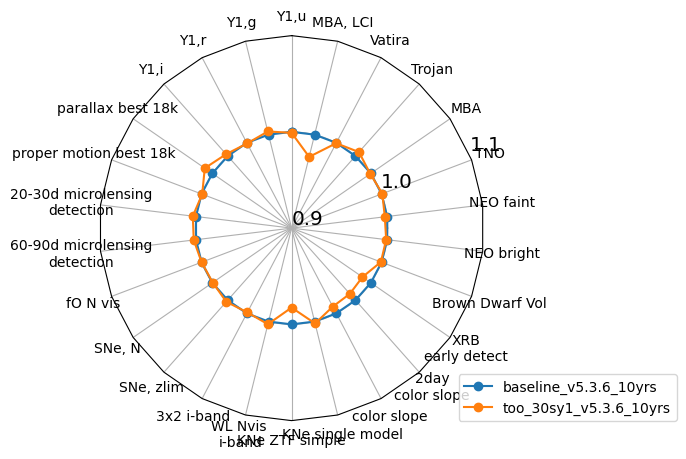

In [19]:
runs = ['baseline_v5.3.6_10yrs'] + [run for run in data_loaded.index if 'too' in run and '5.3.6' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.6_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


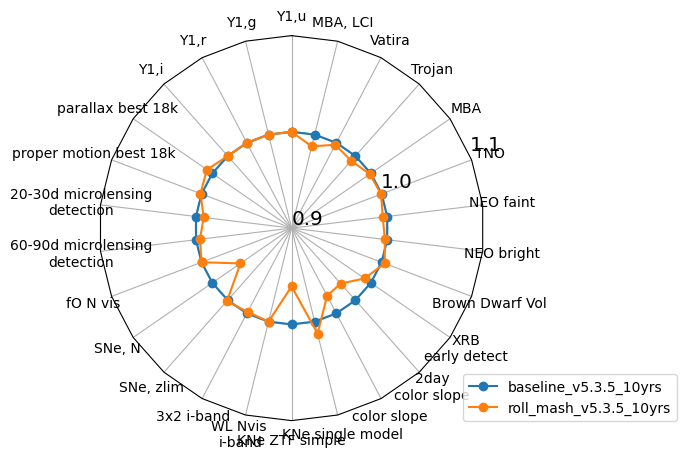

In [20]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'v5.3.5' in run and "mash" in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


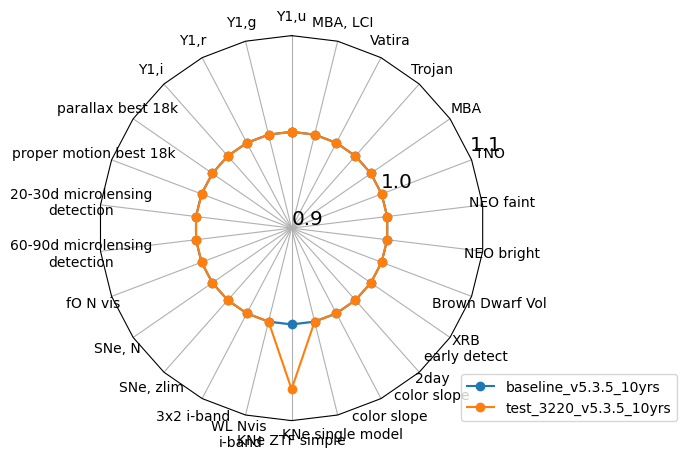

In [21]:
# OK, looks like SP-3220 didn't change any pointings. May have changed some things like target strings
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'test' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


In [22]:
ndata

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira,"MBA, LCI"
run_name,,,,,,,,,,,,,,,,,,,,,
baseline_v5.3.5_10yrs,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
test_3220_v5.3.5_10yrs,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


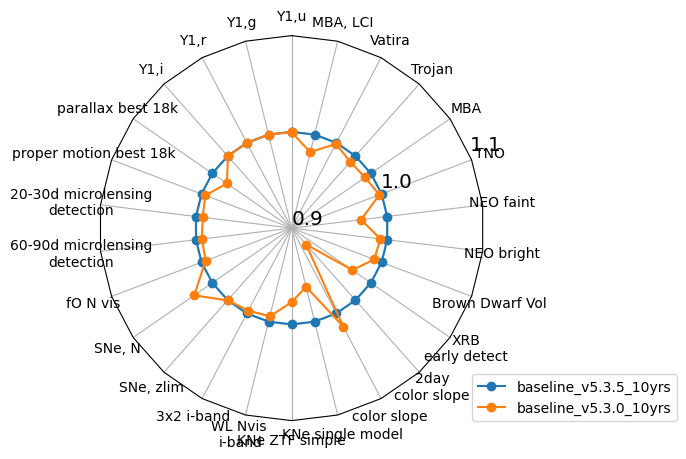

In [23]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'baseline_v5.3.0_10' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


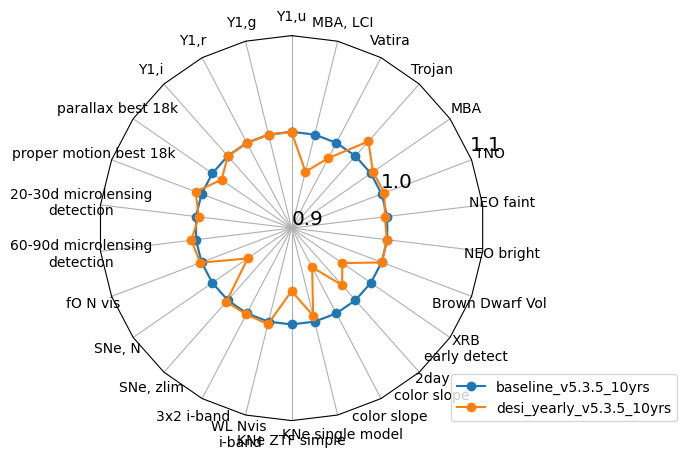

In [24]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'desi_yearly_v5.3.5' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


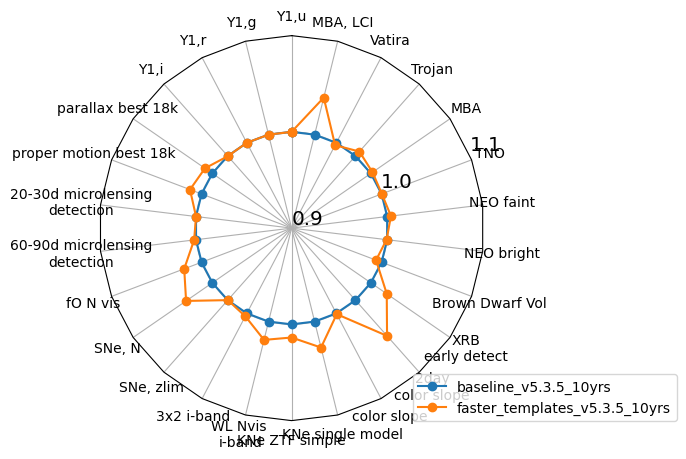

In [25]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'faster' in run and '_v5.3.5' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


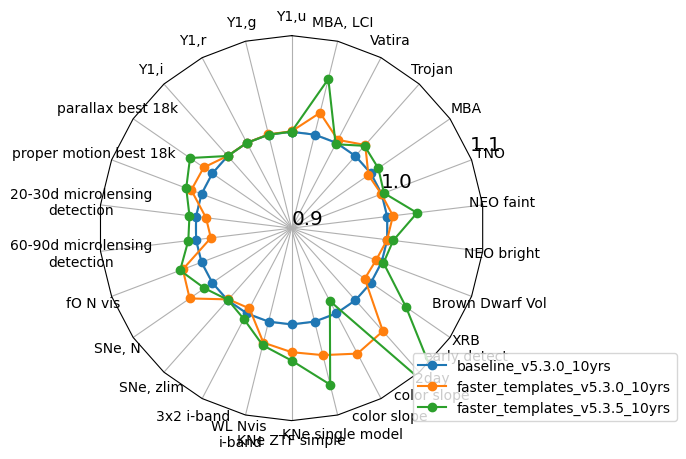

In [26]:
runs = ['baseline_v5.3.0_10yrs'] + [run for run in data_loaded.index if 'faster' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.0_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


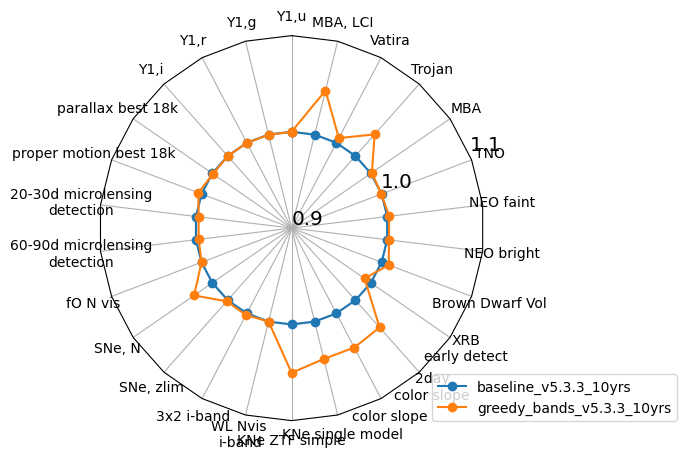

In [27]:
runs = ['baseline_v5.3.3_10yrs'] + [run for run in data_loaded.index if 'greed' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.3_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


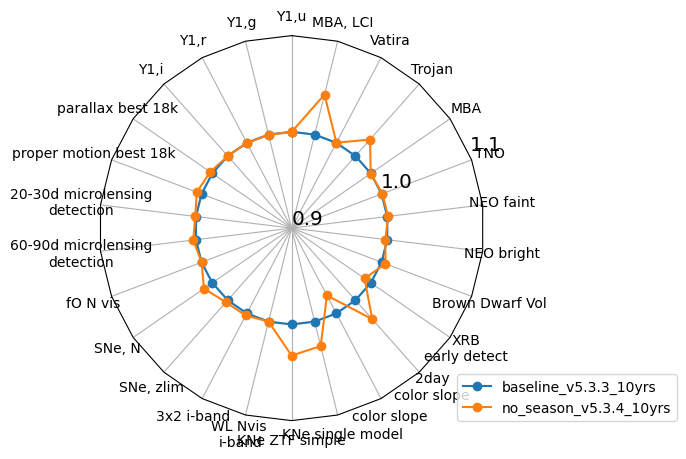

In [28]:
runs = ['baseline_v5.3.3_10yrs'] + [run for run in data_loaded.index if 'no_s' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.3_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


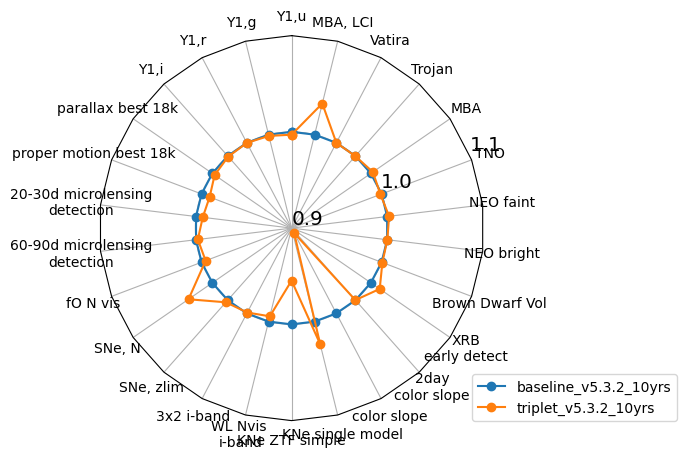

In [29]:
runs = ['baseline_v5.3.2_10yrs'] + [run for run in data_loaded.index if 'trip' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


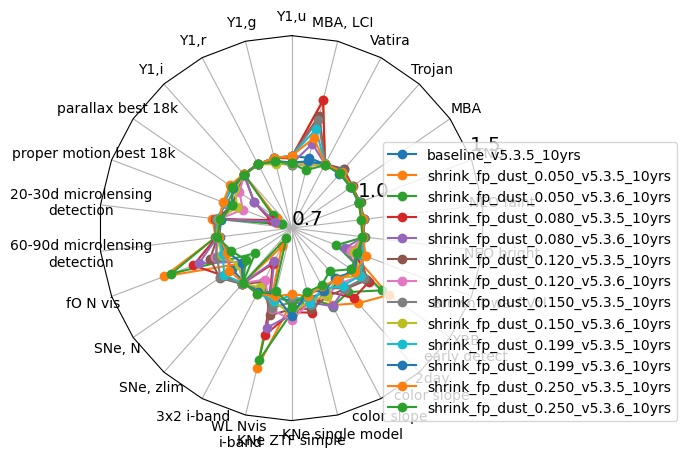

In [30]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'shrink' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.5_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.7, 1.0, 1.5], bbox_to_anchor=(1.5, 0))


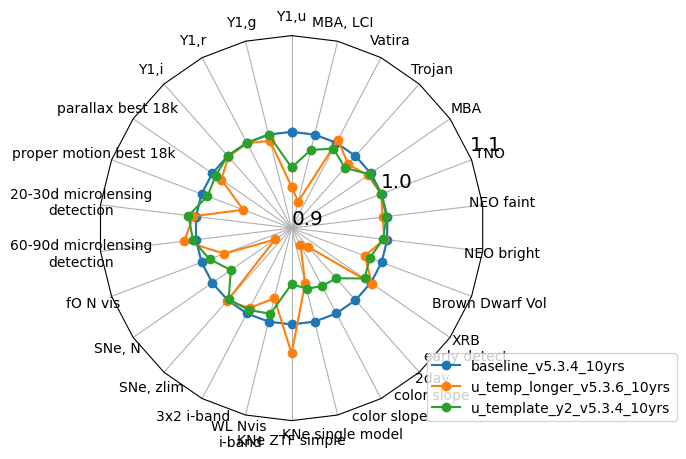

In [31]:
runs = ['baseline_v5.3.4_10yrs'] + [run for run in data_loaded.index if 'u_temp' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.4_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


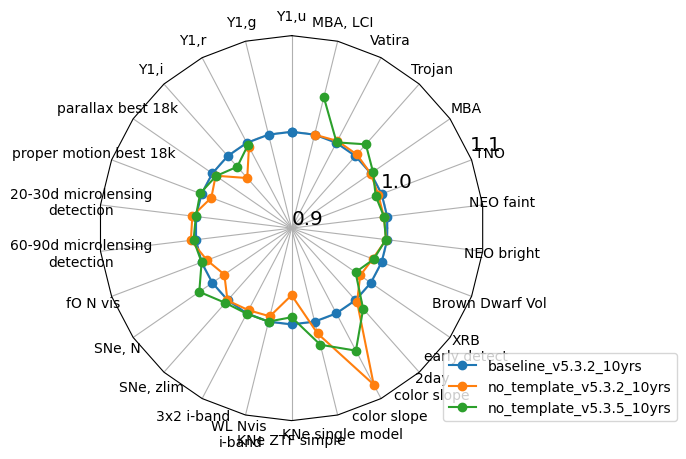

In [32]:
runs = ['baseline_v5.3.2_10yrs'] + [run for run in data_loaded.index if 'no_tem' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


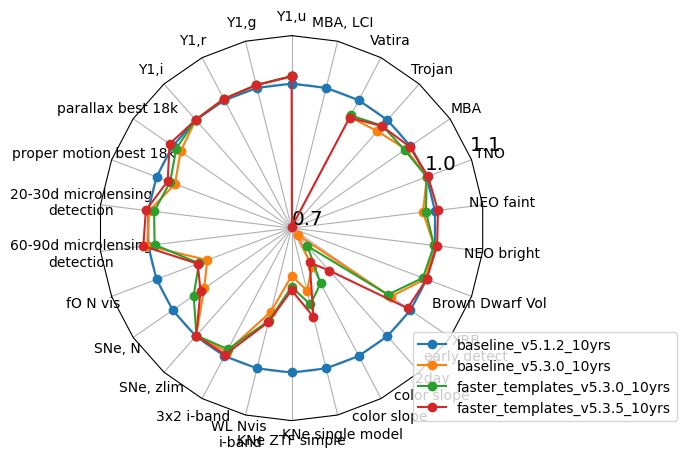

In [33]:
runs = ['baseline_v5.1.2_10yrs' ,'baseline_v5.3.0_10yrs'] + [run for run in data_loaded.index if 'faster' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.1.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.7, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


In [34]:
ndata

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira,"MBA, LCI"
run_name,,,,,,,,,,,,,,,,,,,,,
baseline_v5.1.2_10yrs,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.0000,1.000000,1.000000,...,1.000000,1.00000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000
baseline_v5.3.0_10yrs,1.015162,1.006092,1.003098,1.000371,0.980472,0.958920,0.9982,1.0022,0.887417,0.920771,...,0.718885,0.95049,0.997860,0.9982,0.975122,1.000567,0.988589,0.968898,0.9608,0.663842
faster_templates_v5.3.0_10yrs,1.015729,1.006465,1.003098,1.000618,0.991188,0.969913,0.9878,0.9867,0.905960,0.947156,...,0.749811,0.94327,0.991748,0.9982,0.981217,1.000307,0.985589,0.984307,0.9643,0.679379
faster_templates_v5.3.5_10yrs,1.015446,1.006092,1.003098,1.000494,1.008134,0.975289,1.0051,1.0103,0.908609,0.929962,...,0.817696,0.99278,0.999981,1.0046,1.006434,1.003246,0.998071,0.983143,0.9592,0.703390


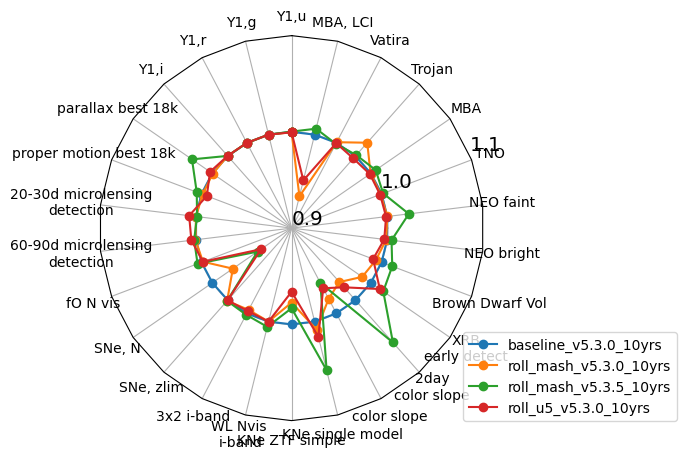

In [35]:
runs = ['baseline_v5.3.0_10yrs'] + [run for run in data_loaded.index if 'roll' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.0_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


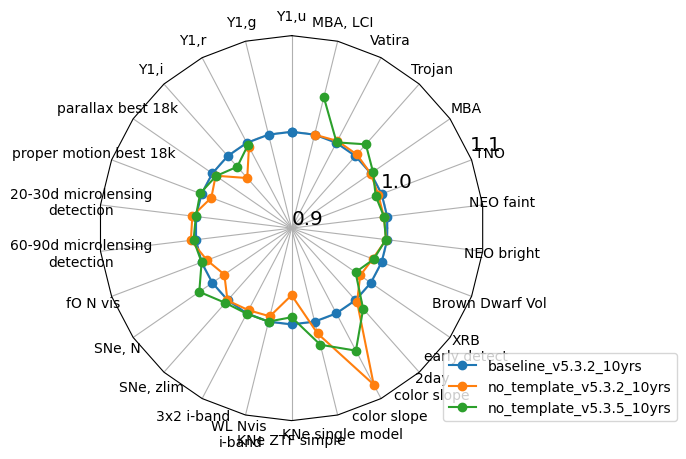

In [36]:
runs = ['baseline_v5.3.2_10yrs'] + [run for run in data_loaded.index if 'no_temp' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


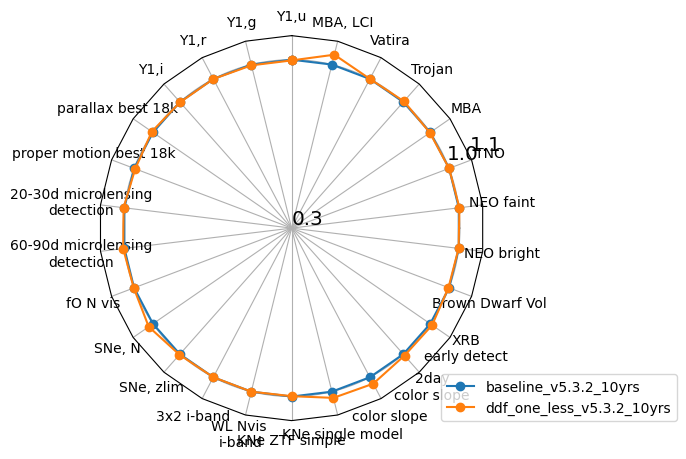

In [37]:
runs = ['baseline_v5.3.2_10yrs'] + [run for run in data_loaded.index if 'one_less' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.3, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


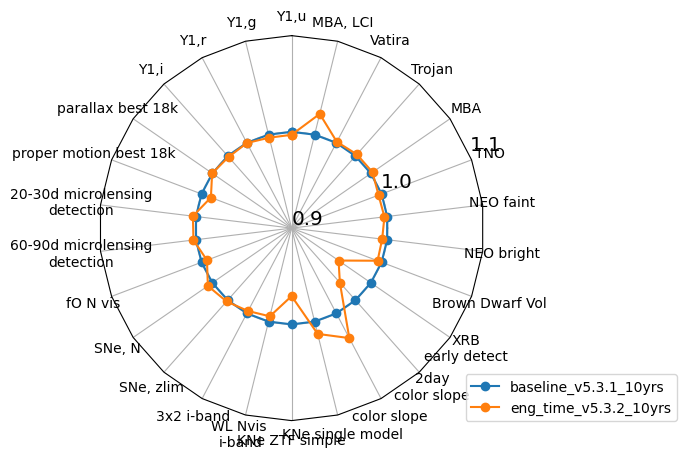

In [38]:
runs = ['baseline_v5.3.1_10yrs'] + [run for run in data_loaded.index if 'eng' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.1_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


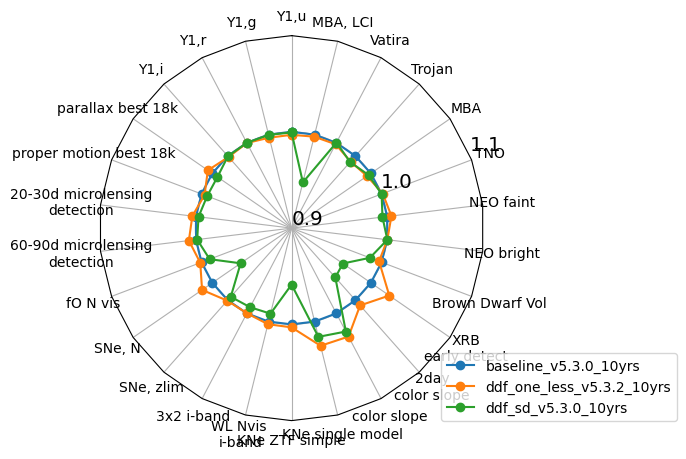

In [39]:
runs = ['baseline_v5.3.0_10yrs'] + [run for run in data_loaded.index if 'ddf' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.0_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


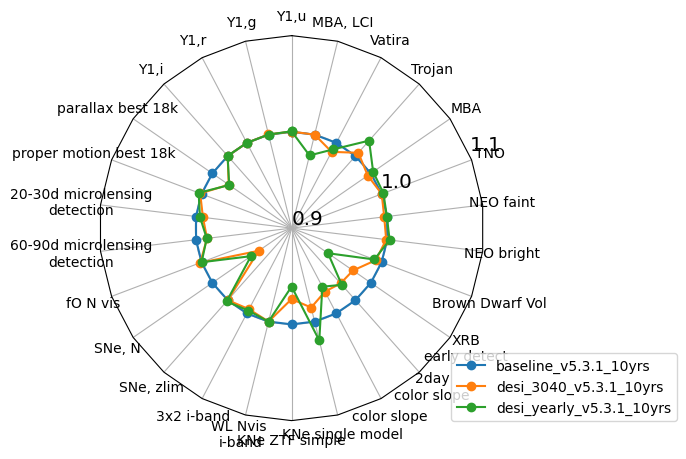

In [40]:
runs = ['baseline_v5.3.1_10yrs'] + [run for run in data_loaded.index if 'desi' in run and '5.3.1' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.1_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


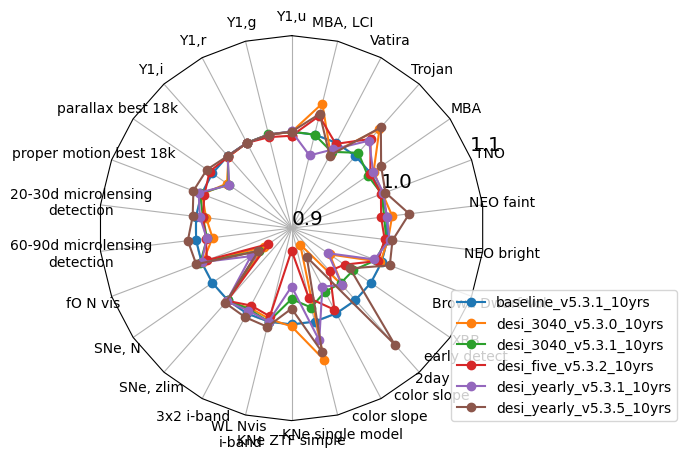

In [41]:
runs = ['baseline_v5.3.1_10yrs'] + [run for run in data_loaded.index if 'desi' in run ] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.1_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


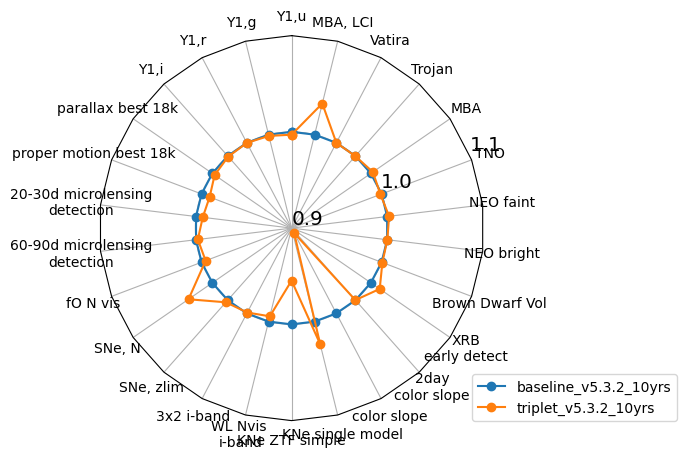

In [42]:
runs = ['baseline_v5.3.2_10yrs'] + [run for run in data_loaded.index if 'trip' in run ] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


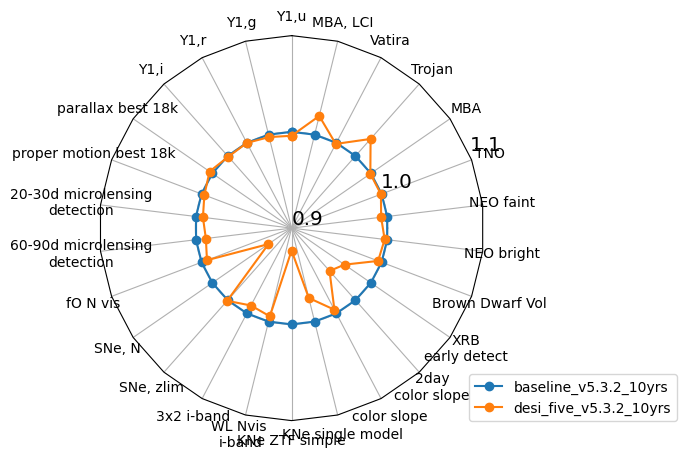

In [43]:
runs = ['baseline_v5.3.2_10yrs'] + [run for run in data_loaded.index if 'desi' in run and '5.3.2' in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.2_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.1], bbox_to_anchor=(1.5, 0))


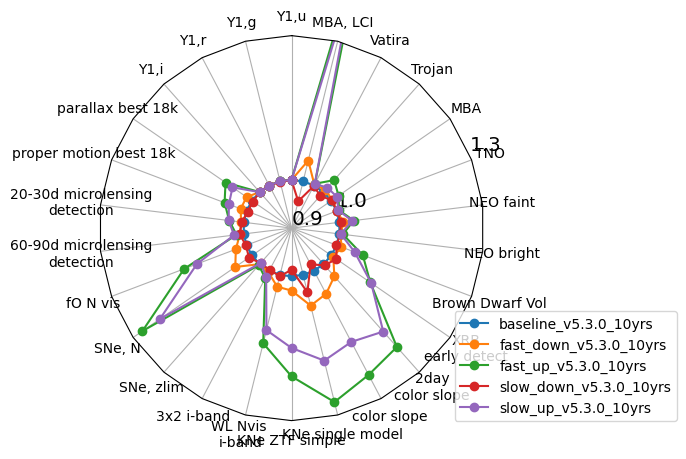

In [44]:
runs = ['baseline_v5.3.0_10yrs'] + [run for run in data_loaded.index if 'fast_' in run or "slow_" in run] 

ndata = norm_df(data, runs, cols=data.columns.values.tolist(),
                invert_cols=invert_cols, mag_cols = mag_cols, norm_run='baseline_v5.3.0_10yrs')
fig, ax = radar(ndata, legend=True, rgrids=[0.9, 1.0, 1.3], bbox_to_anchor=(1.5, 0))


In [45]:
times = ['retro_baseline_v2.0_10yrs', 'baseline_v2.0_10yrs', 'baseline_v2.1_10yrs', 'baseline_v2.2_10yrs',
        'baseline_v3.0_10yrs',  'baseline_v3.2_10yrs', 'baseline_v3.3_10yrs', 'baseline_v3.4_10yrs', 
          'baseline_v3.5_10yrs', 'baseline_v3.6_10yrs', 'baseline_v4.0_10yrs', 'baseline_v4.1_10yrs',
         'baseline_v4.2_10yrs', "baseline_v4.3.5_10yrs","baseline_v5.0.1_10yrs",
          "baseline_v5.1.2_10yrs","comp_survey_v5.2.0_10yrs","comp_survey_v5.3.0_10yrs",
         "comp_survey_v5.3.6_10yrs","baseline_v5.3.1_10yrs",
        "baseline_v5.3.4_10yrs", "baseline_v5.3.5_10yrs", "baseline_v5.3.6_10yrs","baseline_v5.3.6_11yrs",]

sub_data = data.reindex(labels=times)
sub_ddf = ddf_data.reindex(labels=times)
sub_mag = mag_data.reindex(labels=times)
sub_gaps = gaps_data.reindex(labels=times)
sub_data

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira,"MBA, LCI"
run_name,,,,,,,,,,,,,,,,,,,,,
retro_baseline_v2.0_10yrs,0.892997,0.948610,0.960840,0.958493,0.806655,0.177145,0.0877,0.1567,844.0,74866.992902,...,1066656.0,716.0,179114.337158,0.9048,0.623987,0.705883,0.943588,0.666843,0.0000,0.148230
baseline_v2.0_10yrs,0.954102,0.981223,0.994441,0.997035,0.793201,0.184595,0.3116,0.4343,834.0,84521.226481,...,1277708.0,1874.0,167595.204773,0.9294,0.641643,0.719657,0.918853,0.587761,0.0039,0.144029
baseline_v2.1_10yrs,0.947824,0.984064,0.996665,0.999012,0.808880,0.188682,0.3138,0.4315,834.0,83126.586481,...,1271578.0,1917.0,163335.805265,0.9286,0.647493,0.723151,0.927147,0.608476,0.0017,0.150630
baseline_v2.2_10yrs,0.869001,0.913280,0.993576,0.997900,0.794958,0.186814,0.3263,0.4484,826.0,96102.976188,...,1402797.0,1917.0,171949.790286,0.9304,0.657326,0.723757,0.933532,0.615050,0.0008,0.155631
baseline_v3.0_10yrs,0.810826,0.900309,0.993823,0.999135,0.794761,0.186153,0.3227,0.4522,791.0,94711.273608,...,1522131.0,1949.0,167538.768999,0.9326,0.642039,0.722257,0.923939,0.610659,0.0374,0.148630
baseline_v3.2_10yrs,0.973214,0.981841,0.996170,0.995800,0.785002,0.185884,0.3429,0.4865,801.0,107287.044585,...,1430722.0,2045.0,173524.077129,0.9458,0.641833,0.720682,0.926269,0.588185,0.4627,0.144629
baseline_v3.3_10yrs,0.987165,0.992712,0.997529,0.996294,0.756212,0.179475,0.3815,0.5224,807.0,132932.293442,...,1486525.0,2086.0,187648.374486,0.9440,0.659439,0.722520,0.942300,0.629354,0.4601,0.183637
baseline_v3.4_10yrs,0.980887,0.990241,0.995182,0.997406,0.754666,0.178122,0.3650,0.5174,812.0,132121.474272,...,1552620.0,2040.0,188148.511393,0.9472,0.666934,0.727676,0.943417,0.633808,0.4633,0.188238
baseline_v3.5_10yrs,0.982561,0.995059,0.998888,0.997406,0.749014,0.176342,0.3729,0.5189,799.0,114367.709815,...,1379613.0,2130.0,181160.990452,0.9468,0.668745,0.725868,0.938182,0.603993,0.4664,0.161032


/var/folders/jv/jdhmc2t93njct5cx375mztcr0000gn/T/ipykernel_56740/2544528665.py:26: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s" (-> marker='s'). The keyword argument will take precedence.
  h0 = ax.errorbar(np.arange(sub_data[col].values.size), sub_data[col], yerr=std_dict[col], fmt='s', color='k',


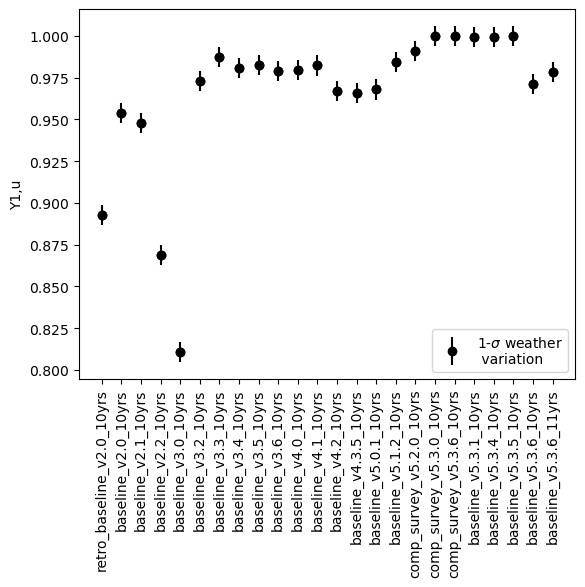

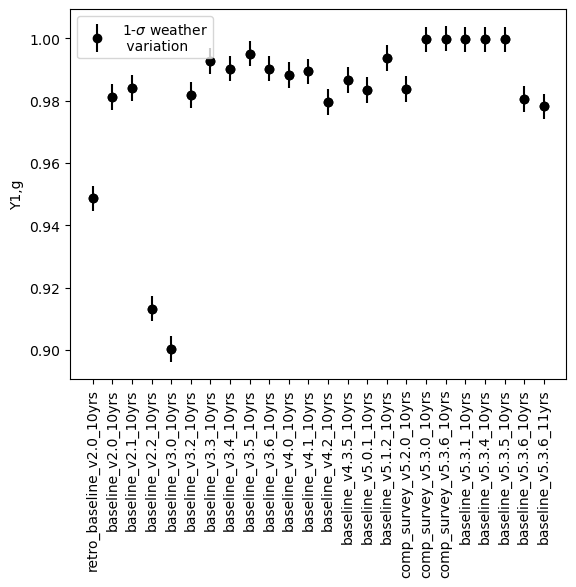

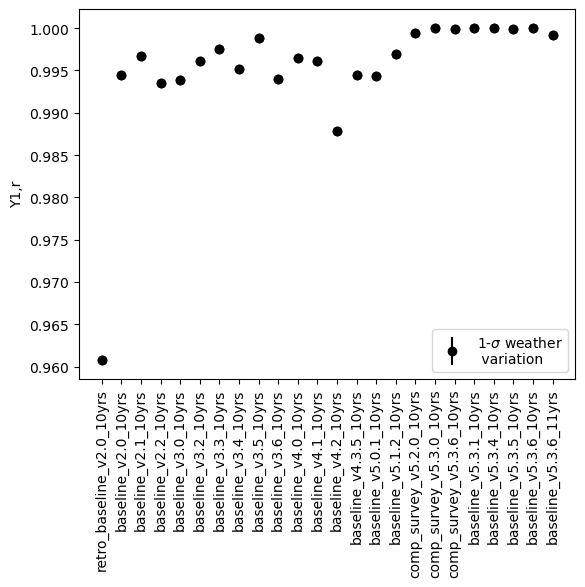

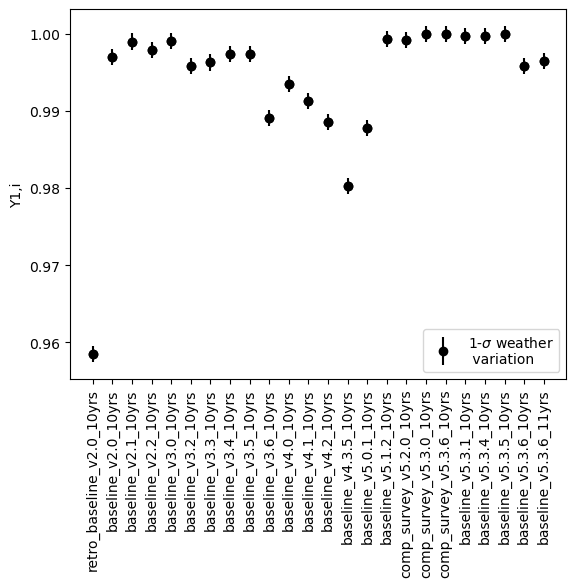

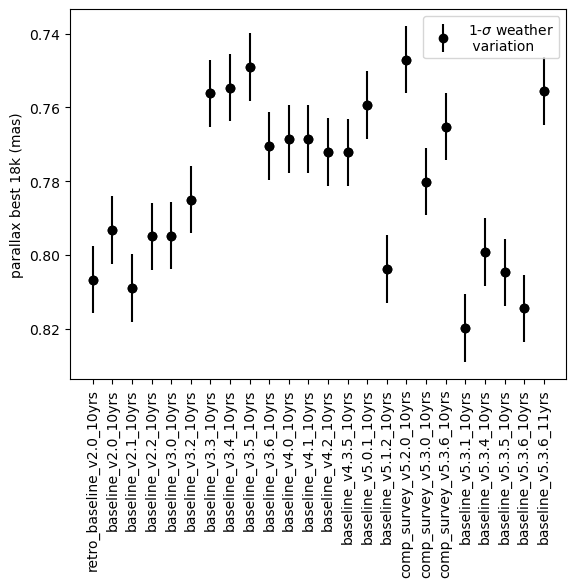

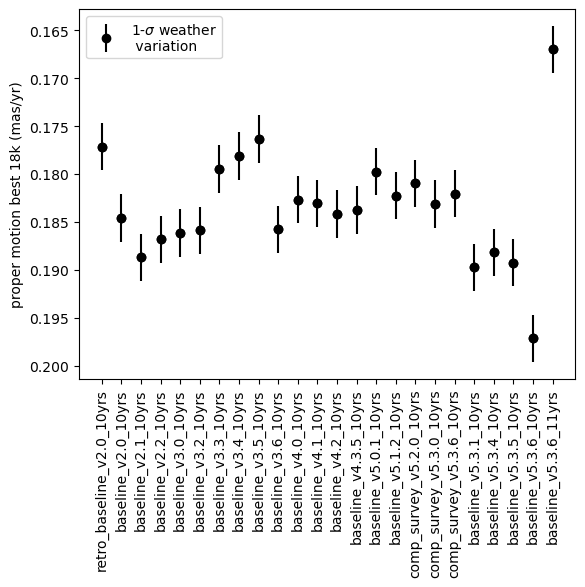

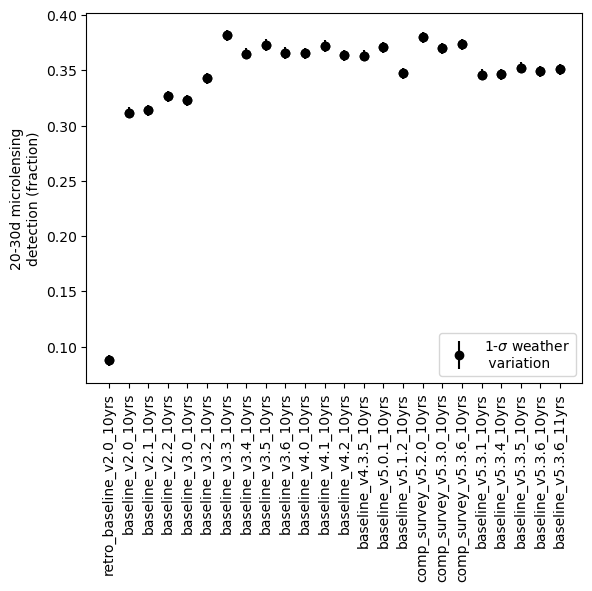

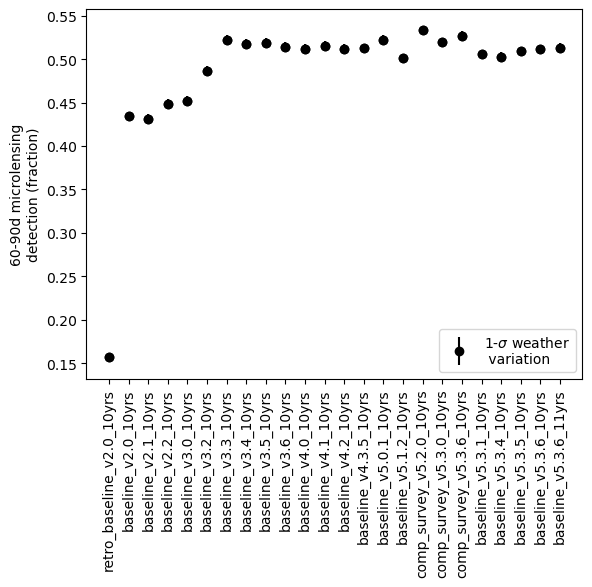

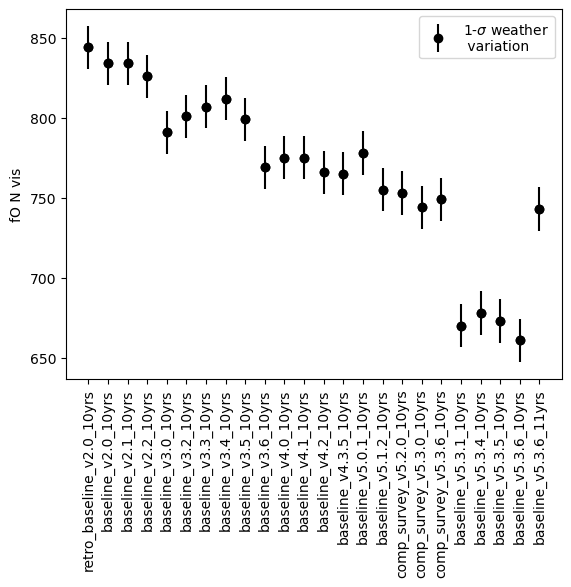

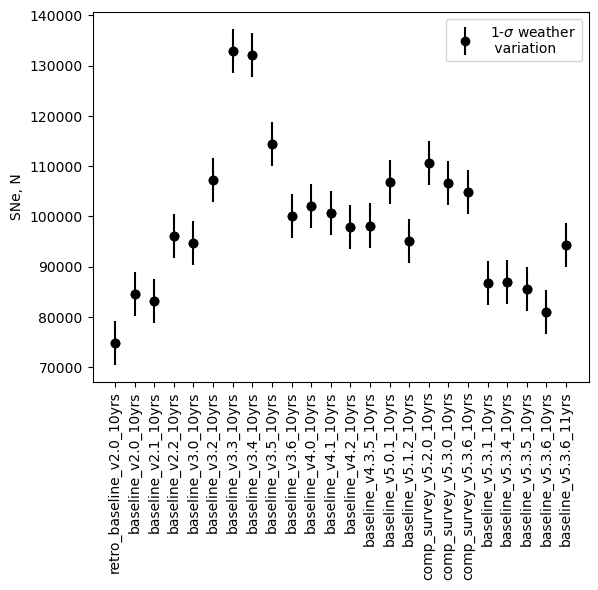

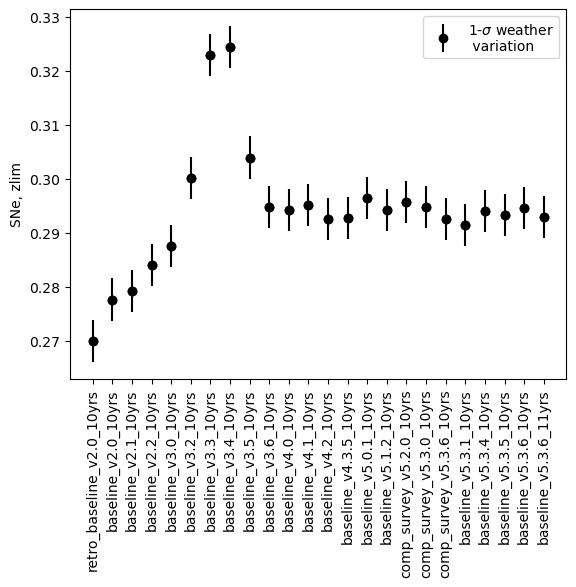

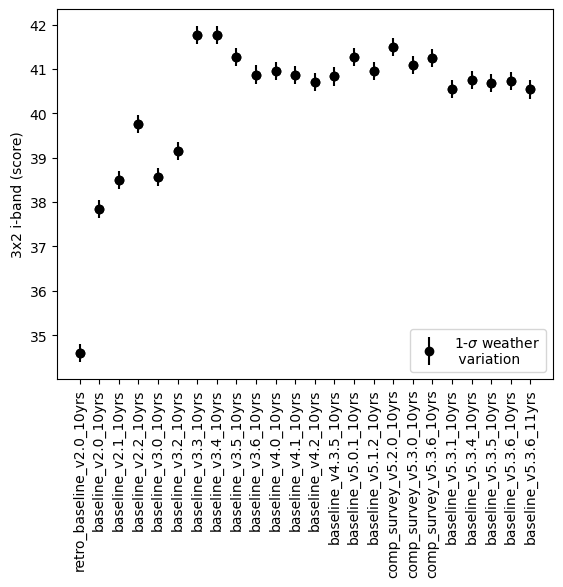

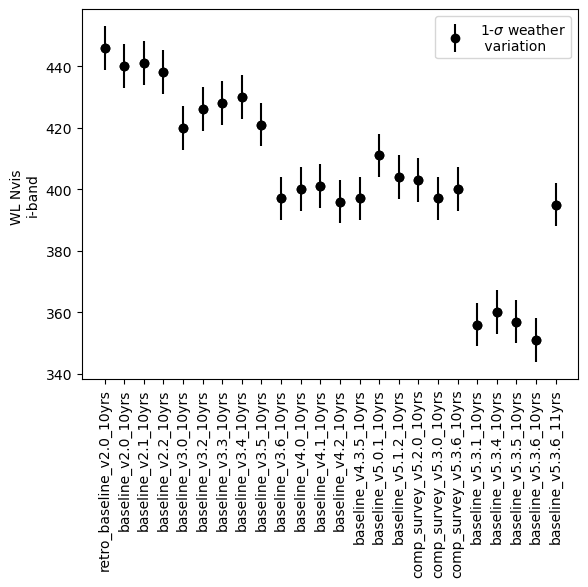

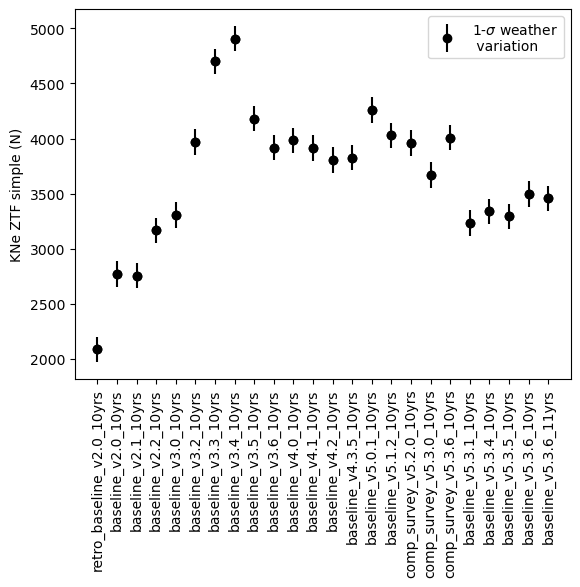

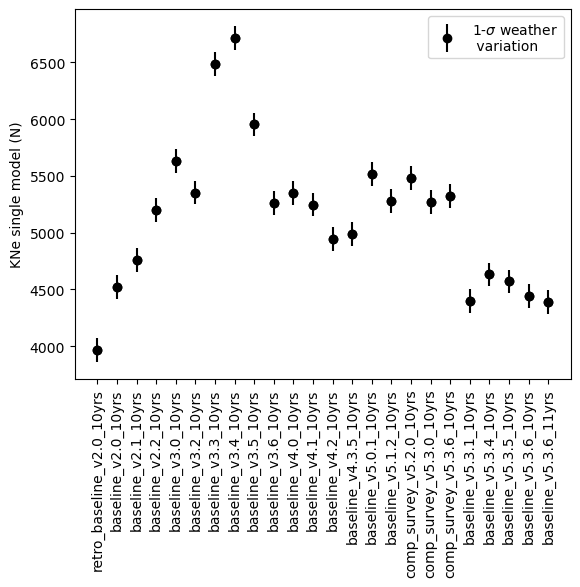

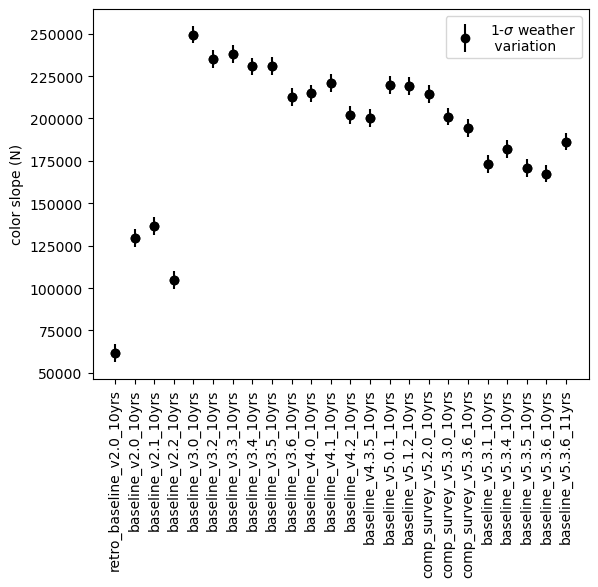

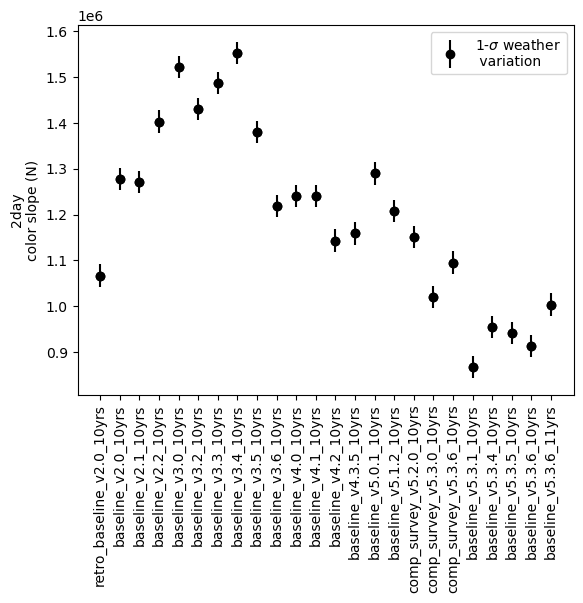

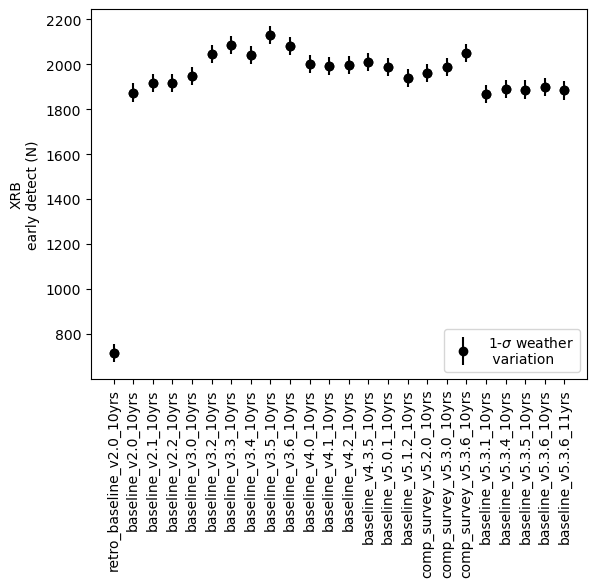

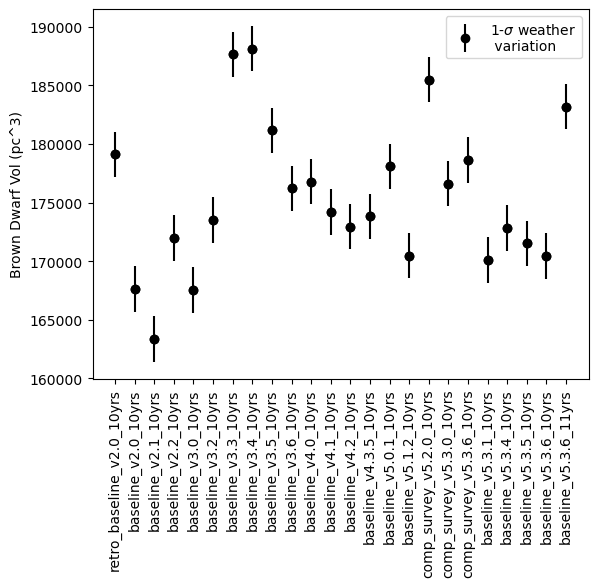

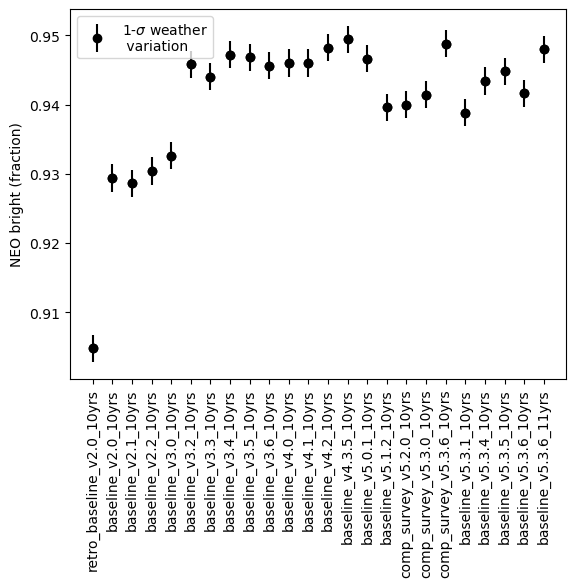

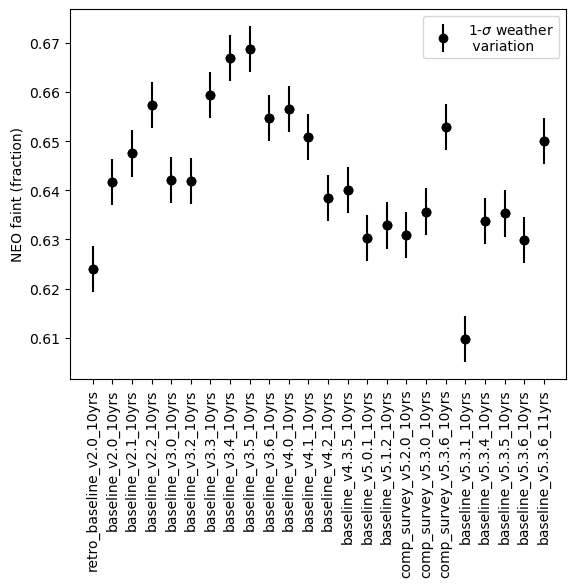

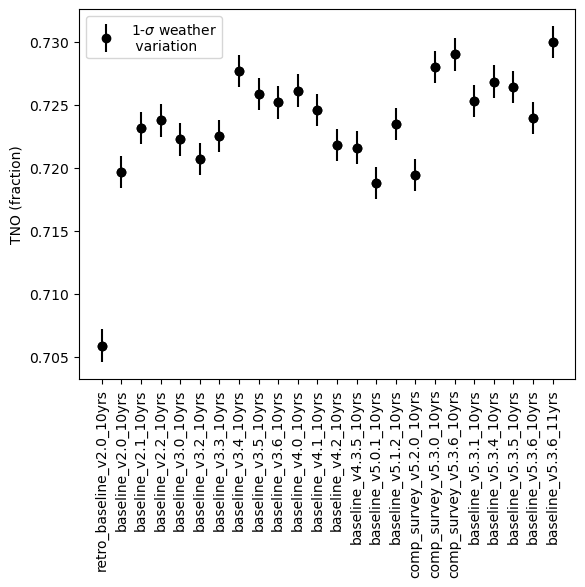

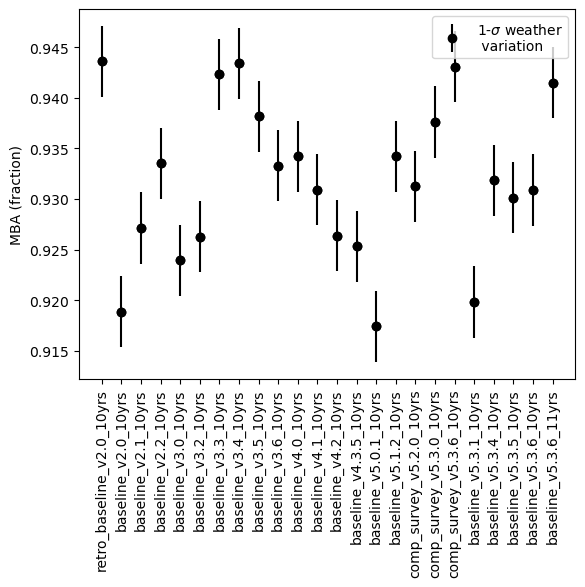

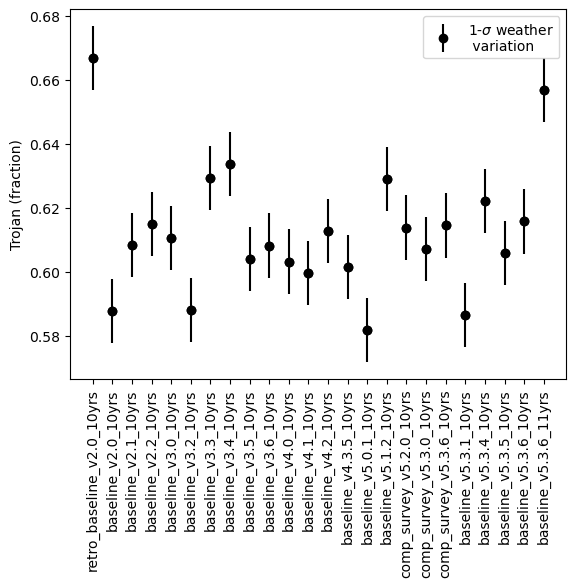

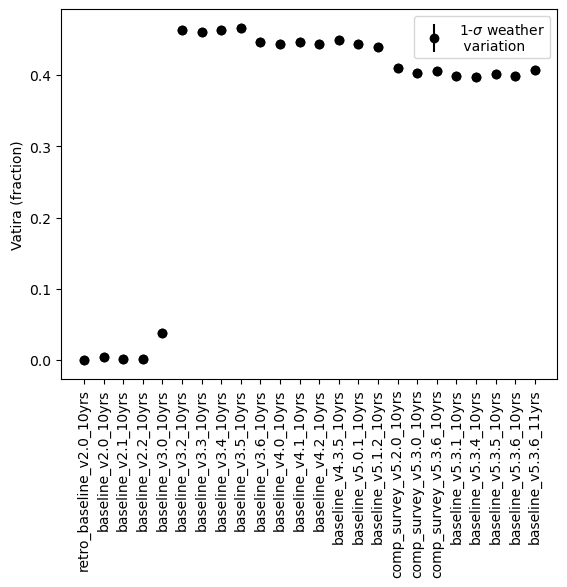

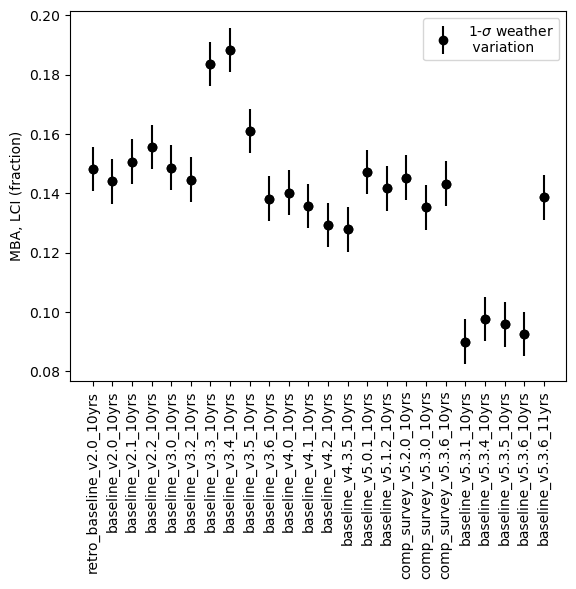

In [46]:
# Rough error bars from weather simulations
std_dict = {}
weather_runs = [run for run in data.index if 'weather' in run and "5.3.0" in run]
for col in data.columns:
    std_dict[col] = np.std(data.loc[weather_runs][col])

std_mag_dict = {}
for col in mag_data.columns:
    std_mag_dict[col] = np.std(mag_data.loc[weather_runs][col])
    
std_ddf_dict = {}
for col in ddf_data.columns:
    std_ddf_dict[col] = np.std(ddf_data.loc[weather_runs][col])
 

std_gaps_dict = {}
for col in gaps_data.columns:
    std_gaps_dict[col] = np.std(gaps_data.loc[weather_runs][col])


#col = data.columns[0]
for col in sub_data.columns:
    fig, ax = plt.subplots()
    ax.plot(sub_data[col], 'ko')
    label_add = ''
    h0 = ax.errorbar(np.arange(sub_data[col].values.size), sub_data[col], yerr=std_dict[col], fmt='s', color='k',
               label=r'1-$\sigma$ weather'
                '\n variation', marker='o')
    if units[col] != '':
        label_add = ' (' + units[col]+')'
    ax.set_ylabel(col + label_add)
    ax.tick_params(axis='x', labelrotation = 90)
    hh=[h0]
    ax.legend(hh, [H.get_label() for H in hh],
        handler_map={type(h0): HandlerErrorbar(xerr_size=1)})
    if col in invert_cols:
        ax.set_ylim(ax.get_ylim()[::-1])

/var/folders/jv/jdhmc2t93njct5cx375mztcr0000gn/T/ipykernel_56740/2837060125.py:7: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s" (-> marker='s'). The keyword argument will take precedence.
  h0 = ax.errorbar(np.arange(sub_data[col].values.size), sub_data[col].values/norm, yerr=std_dict[col]/norm, fmt='s', color='k',


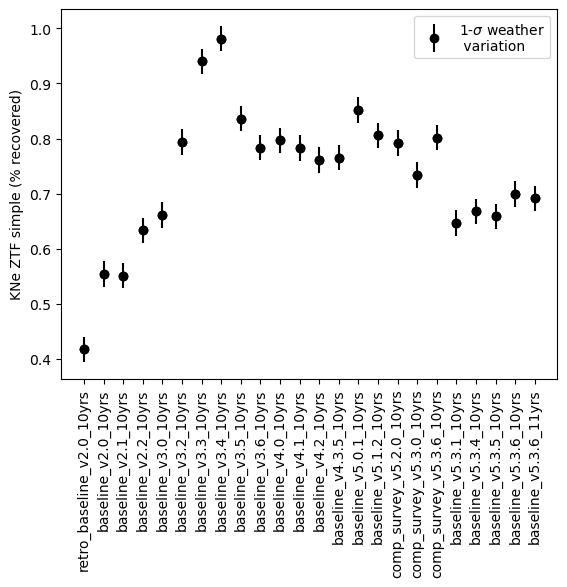

In [47]:
col = 'KNe ZTF simple'

norm = 500000/100
fig, ax = plt.subplots()
ax.plot(sub_data[col]/norm, 'ko')
label_add = ''
h0 = ax.errorbar(np.arange(sub_data[col].values.size), sub_data[col].values/norm, yerr=std_dict[col]/norm, fmt='s', color='k',
           label=r'1-$\sigma$ weather'
            '\n variation', marker='o')

if units[col] != '':
    label_add = ' (' + "% recovered"+')'
ax.set_ylabel(col + label_add)
ax.tick_params(axis='x', labelrotation = 90)
hh=[h0]
ax.legend(hh, [H.get_label() for H in hh],
    handler_map={type(h0): HandlerErrorbar(xerr_size=1)})
if col in invert_cols:
    ax.set_ylim(ax.get_ylim()[::-1])

In [48]:
np.min(data.loc[weather_runs][col]/norm), np.max(data.loc[weather_runs][col]/norm)

(0.6242, 0.7168)

In [49]:
sub_data

,"Y1,u","Y1,g","Y1,r","Y1,i",parallax best 18k,proper motion best 18k,20-30d microlensing\ndetection,60-90d microlensing\ndetection,fO N vis,"SNe, N",...,2day\ncolor slope,XRB\nearly detect,Brown Dwarf Vol,NEO bright,NEO faint,TNO,MBA,Trojan,Vatira,"MBA, LCI"
run_name,,,,,,,,,,,,,,,,,,,,,
retro_baseline_v2.0_10yrs,0.892997,0.948610,0.960840,0.958493,0.806655,0.177145,0.0877,0.1567,844.0,74866.992902,...,1066656.0,716.0,179114.337158,0.9048,0.623987,0.705883,0.943588,0.666843,0.0000,0.148230
baseline_v2.0_10yrs,0.954102,0.981223,0.994441,0.997035,0.793201,0.184595,0.3116,0.4343,834.0,84521.226481,...,1277708.0,1874.0,167595.204773,0.9294,0.641643,0.719657,0.918853,0.587761,0.0039,0.144029
baseline_v2.1_10yrs,0.947824,0.984064,0.996665,0.999012,0.808880,0.188682,0.3138,0.4315,834.0,83126.586481,...,1271578.0,1917.0,163335.805265,0.9286,0.647493,0.723151,0.927147,0.608476,0.0017,0.150630
baseline_v2.2_10yrs,0.869001,0.913280,0.993576,0.997900,0.794958,0.186814,0.3263,0.4484,826.0,96102.976188,...,1402797.0,1917.0,171949.790286,0.9304,0.657326,0.723757,0.933532,0.615050,0.0008,0.155631
baseline_v3.0_10yrs,0.810826,0.900309,0.993823,0.999135,0.794761,0.186153,0.3227,0.4522,791.0,94711.273608,...,1522131.0,1949.0,167538.768999,0.9326,0.642039,0.722257,0.923939,0.610659,0.0374,0.148630
baseline_v3.2_10yrs,0.973214,0.981841,0.996170,0.995800,0.785002,0.185884,0.3429,0.4865,801.0,107287.044585,...,1430722.0,2045.0,173524.077129,0.9458,0.641833,0.720682,0.926269,0.588185,0.4627,0.144629
baseline_v3.3_10yrs,0.987165,0.992712,0.997529,0.996294,0.756212,0.179475,0.3815,0.5224,807.0,132932.293442,...,1486525.0,2086.0,187648.374486,0.9440,0.659439,0.722520,0.942300,0.629354,0.4601,0.183637
baseline_v3.4_10yrs,0.980887,0.990241,0.995182,0.997406,0.754666,0.178122,0.3650,0.5174,812.0,132121.474272,...,1552620.0,2040.0,188148.511393,0.9472,0.666934,0.727676,0.943417,0.633808,0.4633,0.188238
baseline_v3.5_10yrs,0.982561,0.995059,0.998888,0.997406,0.749014,0.176342,0.3729,0.5189,799.0,114367.709815,...,1379613.0,2130.0,181160.990452,0.9468,0.668745,0.725868,0.938182,0.603993,0.4664,0.161032


In [50]:
times = ["baseline_v5.3.0_10yrs","baseline_v5.3.1_10yrs","baseline_v5.3.2_10yrs","baseline_v5.3.3_10yrs",
        "baseline_v5.3.4_10yrs", "baseline_v5.3.5_10yrs", "baseline_v5.3.6_10yrs",]

sub_data = data.reindex(labels=times)
sub_ddf = ddf_data.reindex(labels=times)
sub_mag = mag_data.reindex(labels=times)
sub_gaps = gaps_data.reindex(labels=times)


/var/folders/jv/jdhmc2t93njct5cx375mztcr0000gn/T/ipykernel_56740/681480108.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s" (-> marker='s'). The keyword argument will take precedence.
  h0 = ax.errorbar(np.arange(sub_data[col].values.size), sub_data[col], yerr=std_dict[col], fmt='s', color='k',


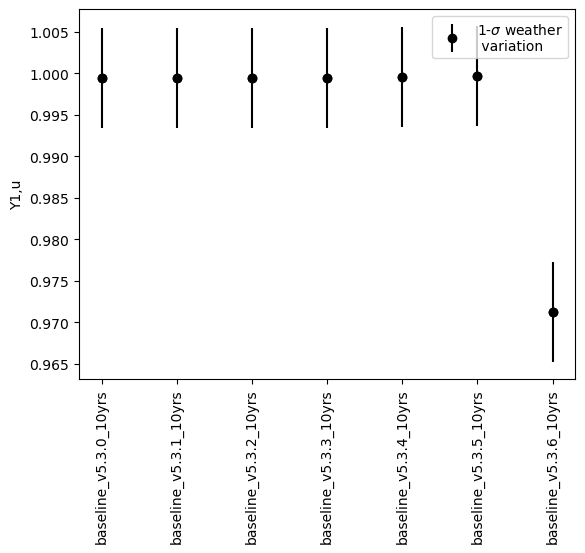

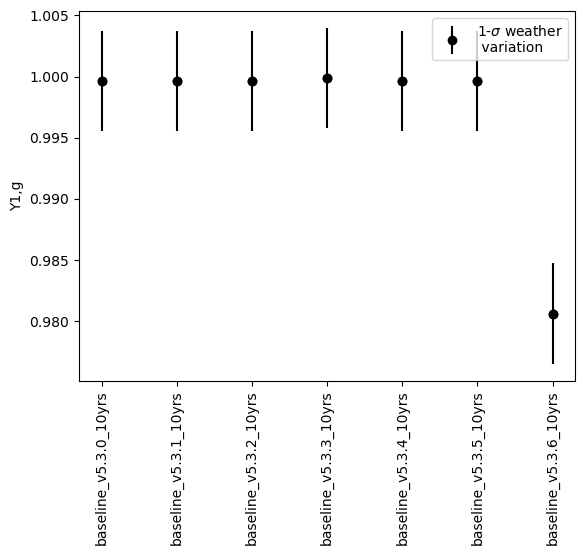

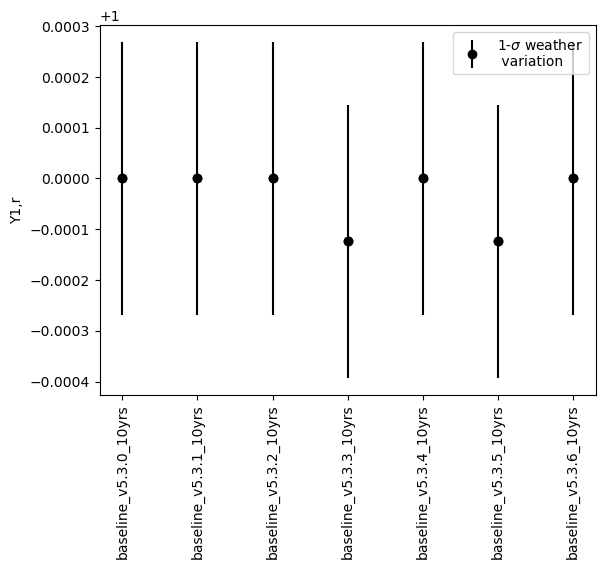

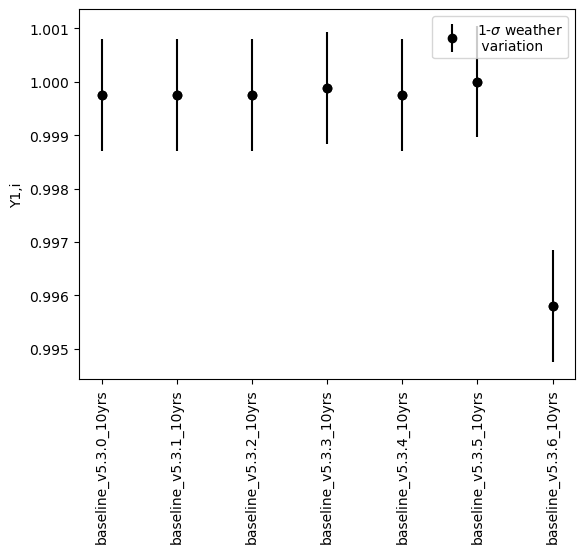

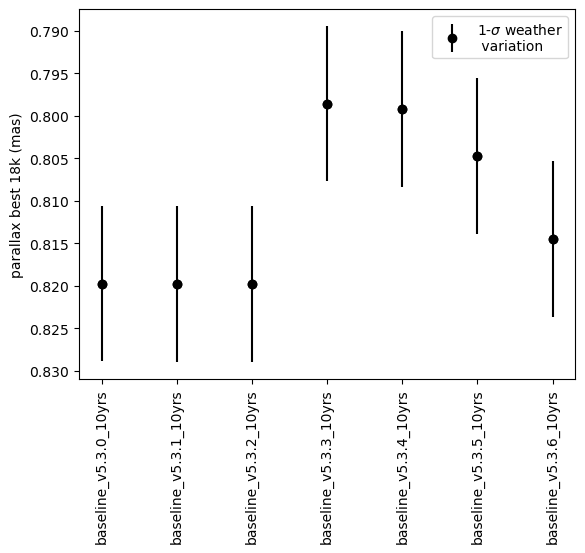

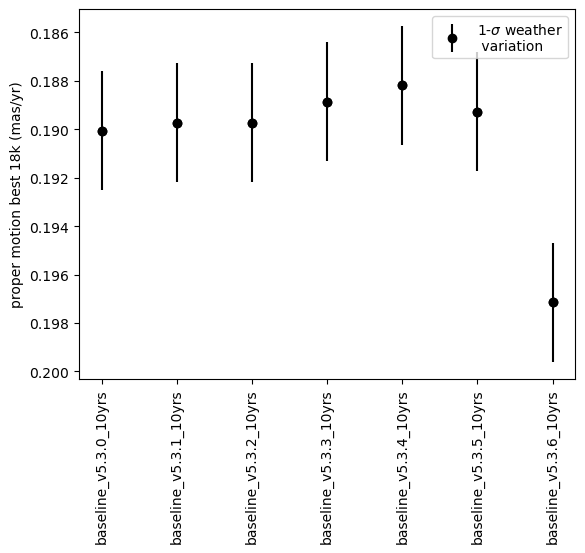

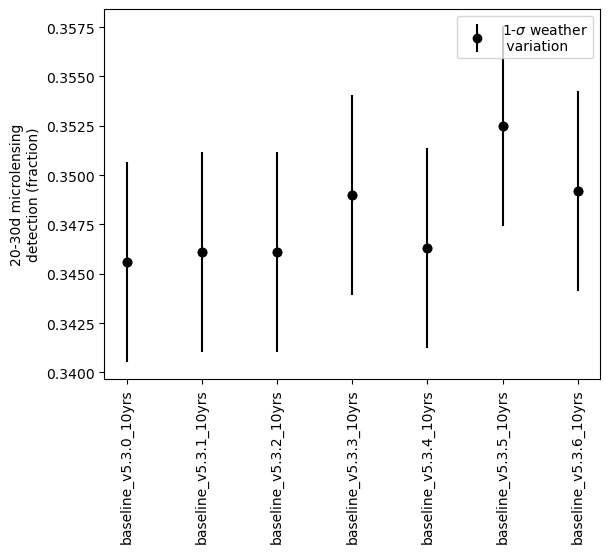

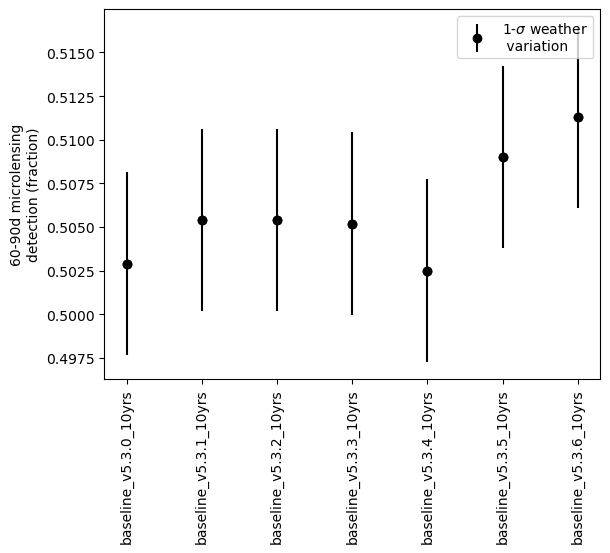

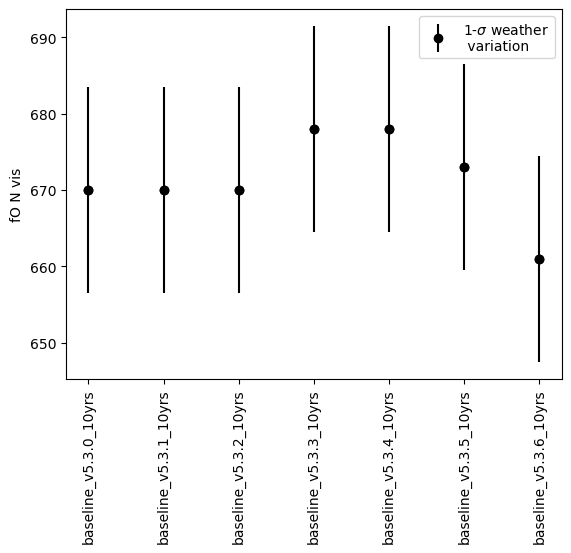

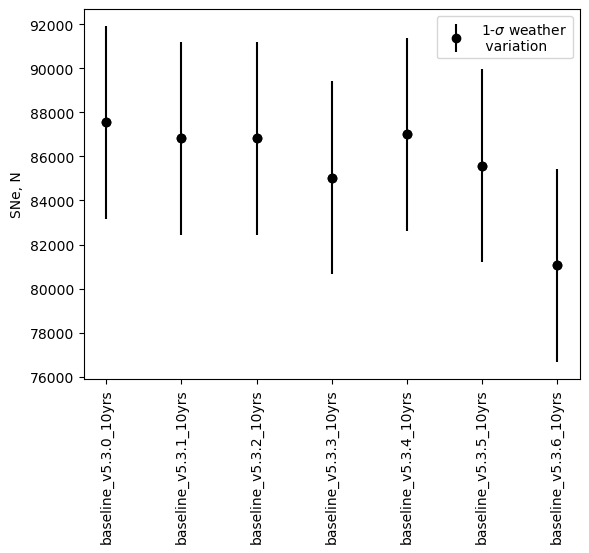

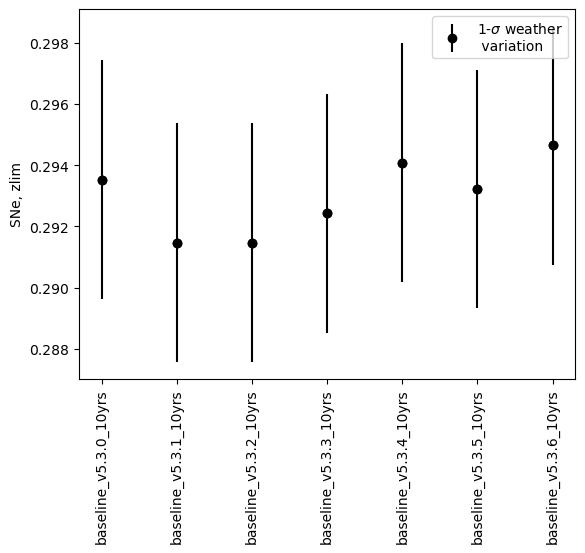

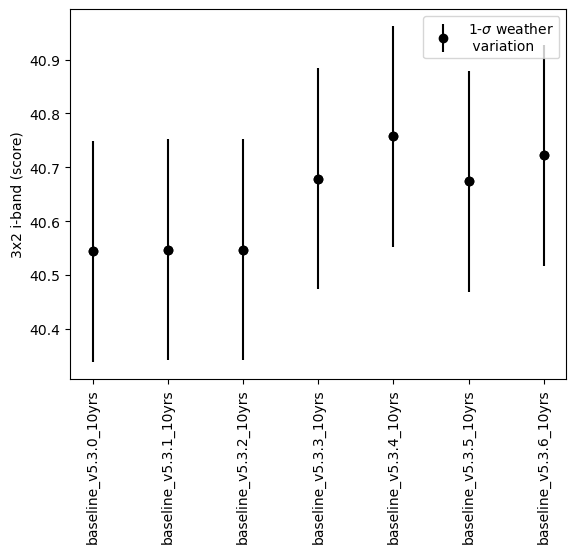

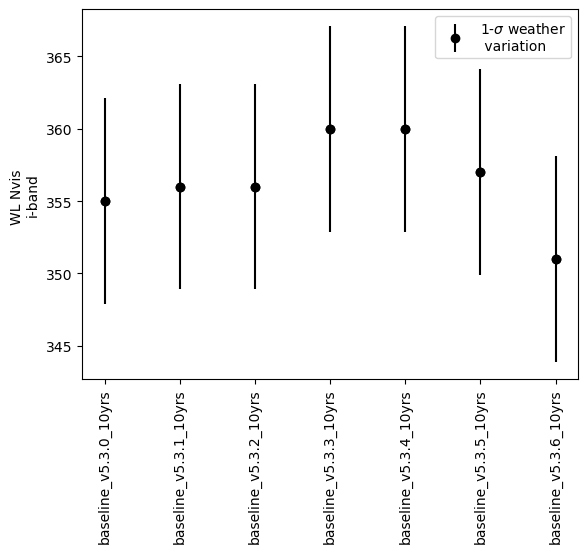

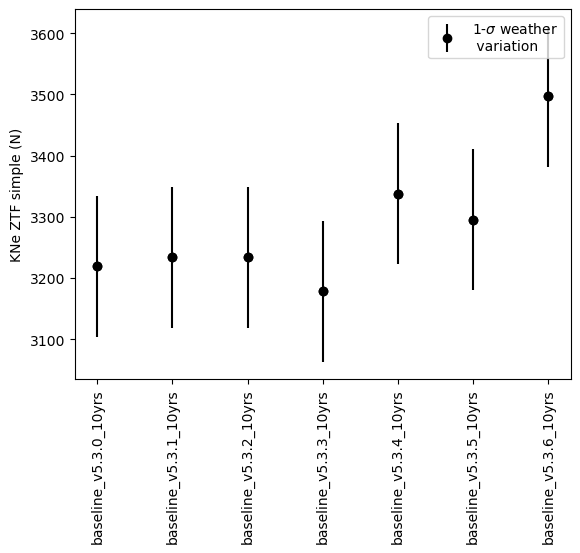

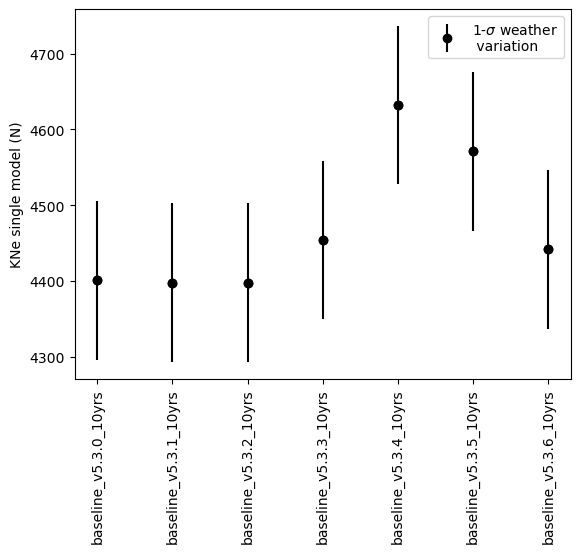

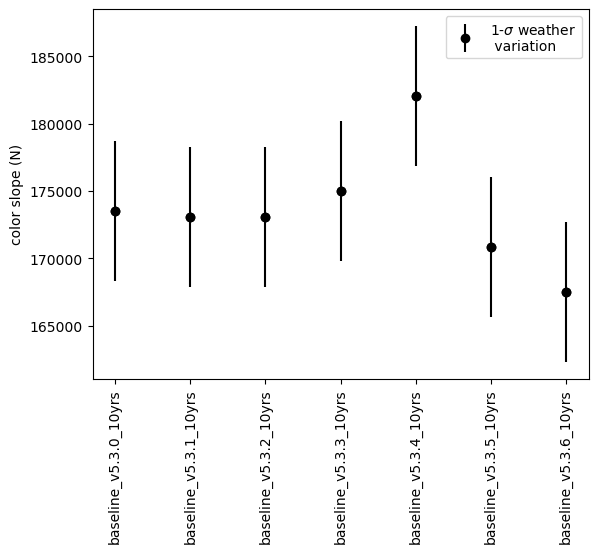

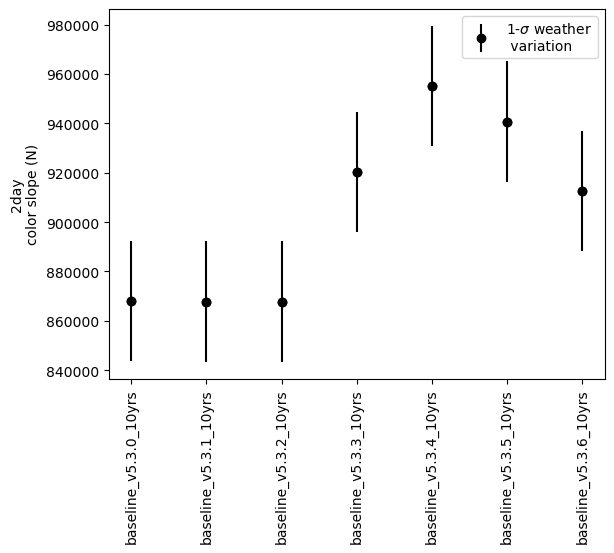

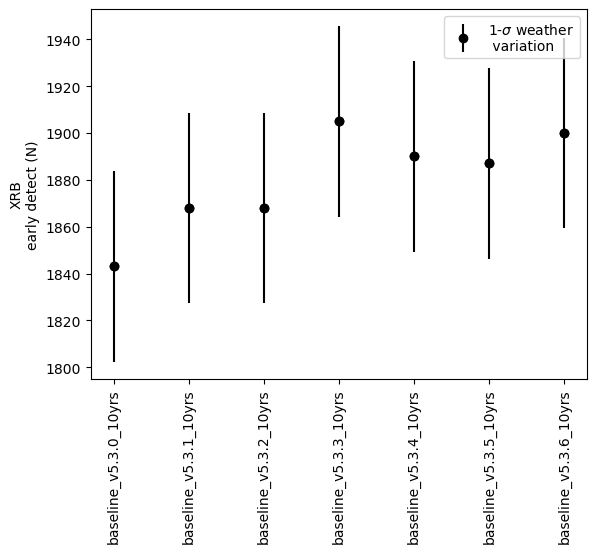

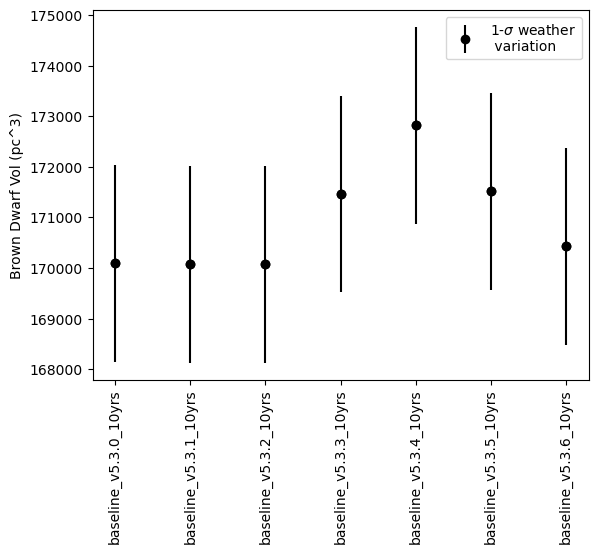

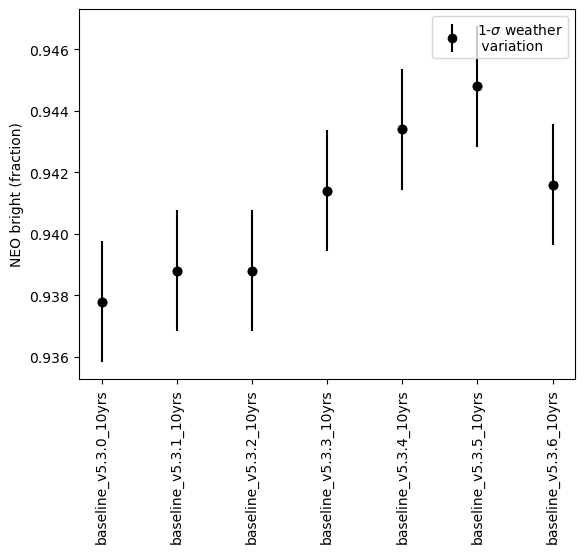

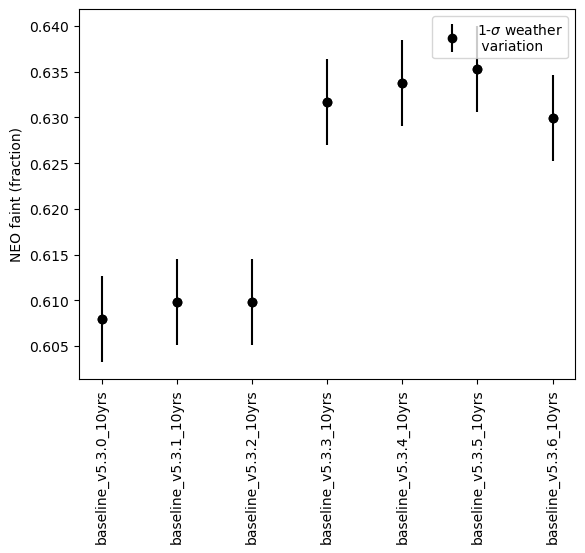

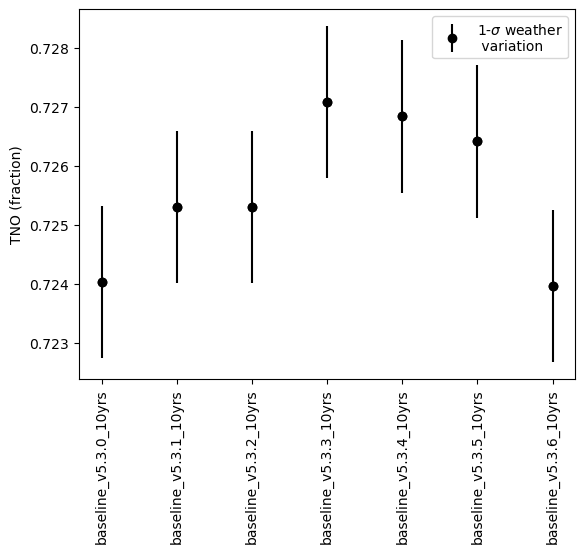

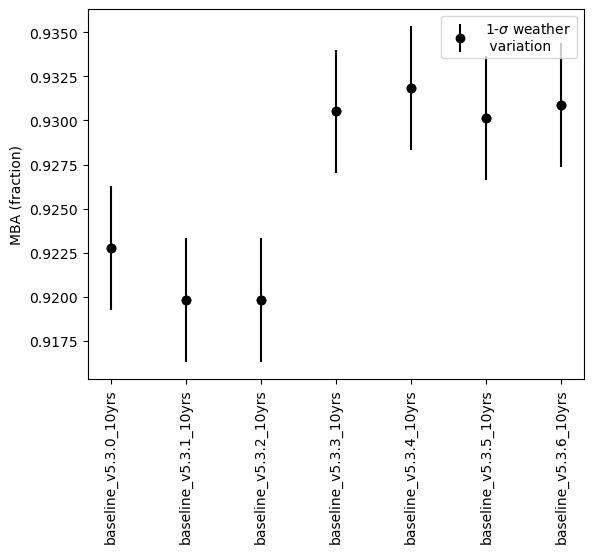

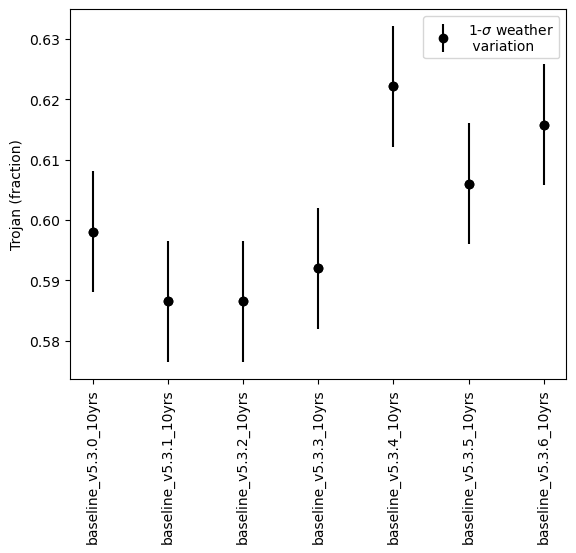

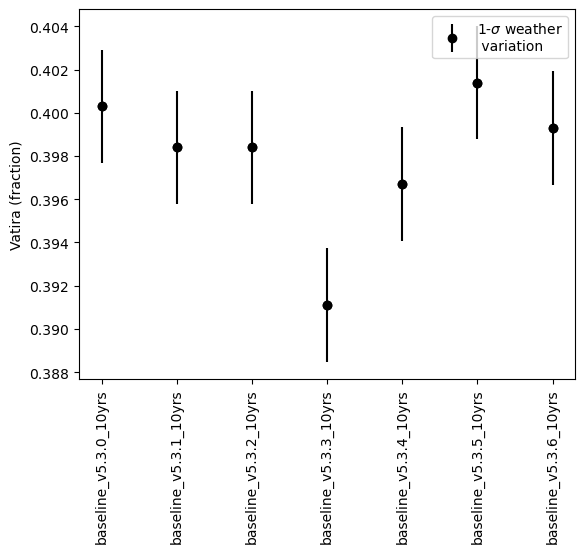

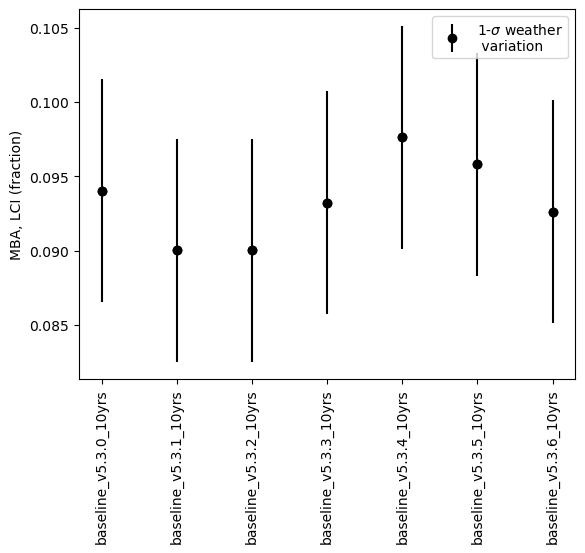

In [51]:


for col in sub_data.columns:
    fig, ax = plt.subplots()
    ax.plot(sub_data[col], 'ko')
    label_add = ''
    h0 = ax.errorbar(np.arange(sub_data[col].values.size), sub_data[col], yerr=std_dict[col], fmt='s', color='k',
               label=r'1-$\sigma$ weather'
                '\n variation', marker='o')
    if units[col] != '':
        label_add = ' (' + units[col]+')'
    ax.set_ylabel(col + label_add)
    ax.tick_params(axis='x', labelrotation = 90)
    hh=[h0]
    ax.legend(hh, [H.get_label() for H in hh],
        handler_map={type(h0): HandlerErrorbar(xerr_size=1)})
    if col in invert_cols:
        ax.set_ylim(ax.get_ylim()[::-1])

In [52]:
std_dict

{'Y1,u': 0.006011240453496268,
 'Y1,g': 0.004104853351035051,
 'Y1,r': 0.0002691233023152099,
 'Y1,i': 0.00104339613537928,
 'parallax best 18k': 0.0091554608324303,
 'proper motion best 18k': 0.0024593298640290997,
 '20-30d microlensing\ndetection': 0.005062469135708389,
 '60-90d microlensing\ndetection': 0.005224667304001286,
 'fO N vis': 13.494066983307887,
 'SNe, N': 4387.813496776621,
 'SNe, zlim': 0.003897208415843751,
 '3x2 i-band': 0.2051786261068757,
 'WL Nvis \ni-band': 7.105235745561156,
 'KNe ZTF simple': 115.0200390149473,
 'KNe single model': 104.65805556071639,
 'color slope': 5190.748969019307,
 '2day\ncolor slope': 24394.234953865125,
 'XRB\nearly detect': 40.6968595225725,
 'Brown Dwarf Vol': 1944.8754381694737,
 'NEO bright': 0.0019617833086250816,
 'NEO faint': 0.0047069202159201635,
 'TNO': 0.0012897541844326703,
 'MBA': 0.00351511166415801,
 'Trojan': 0.01003818247749088,
 'Vatira': 0.0026247618939629503,
 'MBA, LCI': 0.007498572059667781}

In [53]:
cols = [col for col in data_loaded.columns if "3x2" in col]
cols

['3x2ptFoM Exgalm5WithCuts i band non-DD year 1 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 2 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 3 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 4 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 5 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 6 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 7 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 8 HealpixSlicer',
 '3x2ptFoM Exgalm5WithCuts i band non-DD year 9 HealpixSlicer']

In [54]:
runs = ['baseline_v5.3.4_10yrs', 'baseline_v5.1.2_10yrs'] + [run for run in data_loaded.index if 'u_temp' in run] 
indx = np.isin(data_loaded.index, runs)
data_loaded['3x2ptFoM Exgalm5WithCuts i band non-DD year 1 HealpixSlicer'][indx]

run_name
baseline_v5.1.2_10yrs         27.251405
baseline_v5.3.4_10yrs         18.223989
u_temp_longer_v5.3.6_10yrs    19.353386
u_template_y2_v5.3.4_10yrs    18.801300
Name: 3x2ptFoM Exgalm5WithCuts i band non-DD year 1 HealpixSlicer, dtype: float64

In [55]:
runs = ['baseline_v5.3.4_10yrs', 'baseline_v5.1.2_10yrs'] + [run for run in data_loaded.index if 'u_temp' in run] 
indx = np.isin(data_loaded.index, runs)
data_loaded['3x2ptFoM Exgalm5WithCuts i band non-DD year 2 HealpixSlicer'][indx]

run_name
baseline_v5.1.2_10yrs         31.284675
baseline_v5.3.4_10yrs         30.051609
u_temp_longer_v5.3.6_10yrs    25.622652
u_template_y2_v5.3.4_10yrs    30.357271
Name: 3x2ptFoM Exgalm5WithCuts i band non-DD year 2 HealpixSlicer, dtype: float64

In [56]:
runs = ['baseline_v5.3.4_10yrs', 'baseline_v5.1.2_10yrs'] + [run for run in data_loaded.index if 'u_temp' in run] 
indx = np.isin(data_loaded.index, runs)
data_loaded['3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer'][indx]

run_name
baseline_v5.1.2_10yrs         40.952113
baseline_v5.3.4_10yrs         40.757555
u_temp_longer_v5.3.6_10yrs    40.499735
u_template_y2_v5.3.4_10yrs    40.595407
Name: 3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer, dtype: float64

In [57]:
[col for col in data_loaded.columns if "Surface" in col]

['Median SurfaceBrightLimit g HealpixSlicer',
 'Median SurfaceBrightLimit i HealpixSlicer',
 'Median SurfaceBrightLimit r HealpixSlicer',
 'Median SurfaceBrightLimit u HealpixSlicer',
 'Median SurfaceBrightLimit y HealpixSlicer',
 'Median SurfaceBrightLimit z HealpixSlicer']

In [58]:
data_loaded["Median SurfaceBrightLimit r HealpixSlicer"][times]

run_name
baseline_v5.3.0_10yrs    30.285952
baseline_v5.3.1_10yrs    30.284638
baseline_v5.3.2_10yrs    30.284638
baseline_v5.3.3_10yrs    30.311534
baseline_v5.3.4_10yrs    30.316148
baseline_v5.3.5_10yrs    30.312102
baseline_v5.3.6_10yrs    30.309850
Name: Median SurfaceBrightLimit r HealpixSlicer, dtype: float64

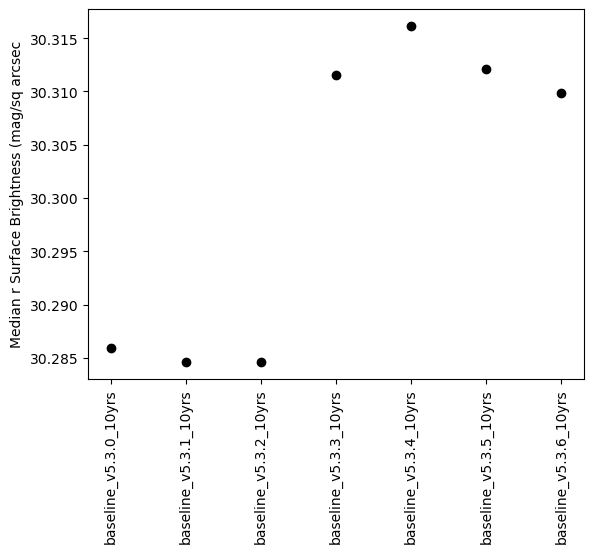

In [59]:
fig, ax = plt.subplots()
ax.plot(data_loaded["Median SurfaceBrightLimit r HealpixSlicer"][times], 'ko')
label_add = ''
ax.set_ylabel("Median r Surface Brightness (mag/sq arcsec")
ax.tick_params(axis='x', labelrotation = 90)



In [60]:
runs = ['baseline_v5.3.5_10yrs'] + [run for run in data_loaded.index if 'shrink' in run] 
indx = np.isin(data_loaded.index, runs)

In [61]:
data_loaded[indx]

metric,10th%ile CoaddM5 HealpixSlicer,10th%ile CoaddM5 g HealpixSlicer,10th%ile CoaddM5 i HealpixSlicer,10th%ile CoaddM5 r HealpixSlicer,10th%ile CoaddM5 u HealpixSlicer,10th%ile CoaddM5 y HealpixSlicer,10th%ile CoaddM5 z HealpixSlicer,10th%ile Count observationStartMJD HealpixSlicer,10th%ile Count observationStartMJD g HealpixSlicer,10th%ile Count observationStartMJD i HealpixSlicer,...,top18k N ToO g and scheduler_note like ToO% HealpixSlicer,top18k N ToO i and scheduler_note like ToO% HealpixSlicer,top18k N ToO r and scheduler_note like ToO% HealpixSlicer,top18k N ToO u and scheduler_note like ToO% HealpixSlicer,top18k N ToO y and scheduler_note like ToO% HealpixSlicer,top18k N ToO z and scheduler_note like ToO% HealpixSlicer,top18k Year1.0Count night < 365.25 HealpixSlicer,top18k Year2.5Count night > 913.125000 and night < 1278.375000 HealpixSlicer,top18k Year3.5Count night > 1278.375000 and night < 1643.625000 HealpixSlicer,"best18k Parallax fiveSigmaDepth, filter, seeingFwhmGeom, ra_pi_amp, dec_pi_amp HealpixSlicer"
run_name,,,,,,,,,,,,,,,,,,,,,
baseline_v5.3.5_10yrs,26.528886,26.169910,25.327131,25.932727,24.896483,23.696861,24.614233,163.0,31.0,43.0,...,1.0,1.0,1.0,1.0,1.0,1.0,50.0,25.0,44.0,0.804713
shrink_fp_dust_0.050_v5.3.5_10yrs,26.540350,26.146060,25.422224,25.928754,24.611502,23.754063,24.674407,194.0,23.0,51.0,...,1.0,1.0,1.0,1.0,1.0,1.0,47.0,23.0,25.0,1.038724
shrink_fp_dust_0.050_v5.3.6_10yrs,26.570781,26.244652,25.342333,25.927512,24.696212,23.446394,24.663649,195.0,38.0,46.0,...,1.0,1.0,1.0,1.0,1.0,1.0,38.0,25.0,27.0,1.011340
shrink_fp_dust_0.080_v5.3.5_10yrs,26.508157,26.108496,25.400367,25.901175,24.680857,23.804450,24.618348,174.0,22.0,47.0,...,1.0,1.0,1.0,1.0,1.0,1.0,48.0,23.0,27.0,0.905771
shrink_fp_dust_0.080_v5.3.6_10yrs,26.533687,26.190526,25.334077,25.892596,24.683546,23.520779,24.637237,177.0,34.0,43.0,...,1.0,1.0,1.0,1.0,1.0,1.0,39.0,28.0,30.0,0.904942
shrink_fp_dust_0.120_v5.3.5_10yrs,26.482947,26.100408,25.355364,25.870532,24.738716,23.859310,24.599600,166.0,23.0,46.0,...,1.0,1.0,1.0,1.0,1.0,1.0,49.0,24.0,39.0,0.827916
shrink_fp_dust_0.120_v5.3.6_10yrs,26.505803,26.173442,25.308927,25.867962,24.754133,23.587642,24.591297,166.0,32.0,42.0,...,1.0,1.0,1.0,1.0,1.0,1.0,39.0,26.0,39.0,0.835123
shrink_fp_dust_0.150_v5.3.5_10yrs,26.479771,26.087827,25.353786,25.888448,24.780815,23.890824,24.625830,162.0,24.0,45.0,...,1.0,1.0,1.0,1.0,1.0,1.0,49.0,24.0,42.0,0.815506
shrink_fp_dust_0.150_v5.3.6_10yrs,26.521964,26.179214,25.303492,25.896054,24.807565,23.610571,24.581744,160.0,31.0,42.0,...,1.0,1.0,1.0,1.0,1.0,1.0,39.0,27.0,41.0,0.818359


In [62]:
cols = [col for col in data_loaded.columns if "FractionPop 2" in col and "MBA" in col and "H = 20.0" in col]

In [63]:
data_loaded[cols][indx]

metric,"FractionPop 2 of g, r or i, z or y H = 20.000000 ColorAsteroid MBA MoObjSlicer"
run_name,
baseline_v5.3.5_10yrs,0.071014
shrink_fp_dust_0.050_v5.3.5_10yrs,0.066013
shrink_fp_dust_0.050_v5.3.6_10yrs,0.068614
shrink_fp_dust_0.080_v5.3.5_10yrs,0.072014
shrink_fp_dust_0.080_v5.3.6_10yrs,0.071814
shrink_fp_dust_0.120_v5.3.5_10yrs,0.074215
shrink_fp_dust_0.120_v5.3.6_10yrs,0.076015
shrink_fp_dust_0.150_v5.3.5_10yrs,0.068414
shrink_fp_dust_0.150_v5.3.6_10yrs,0.076615


In [64]:
times = ['retro_baseline_v2.0_10yrs', 'baseline_v2.0_10yrs', 'baseline_v2.1_10yrs', 'baseline_v2.2_10yrs',
        'baseline_v3.0_10yrs',  'baseline_v3.2_10yrs', 'baseline_v3.3_10yrs', 'baseline_v3.4_10yrs', 
          'baseline_v3.5_10yrs', 'baseline_v3.6_10yrs', 'baseline_v4.0_10yrs', 'baseline_v4.1_10yrs',
         'baseline_v4.2_10yrs', "baseline_v4.3.5_10yrs","baseline_v5.0.1_10yrs",
          "baseline_v5.1.2_10yrs", "comp_survey_v5.2.0_10yrs","comp_survey_v5.3.0_10yrs","baseline_v5.3.0_10yrs", "baseline_v5.3.1_10yrs",
        "baseline_v5.3.2_10yrs","baseline_v5.3.3_10yrs", "baseline_v5.3.4_10yrs", "baseline_v5.3.5_10yrs", "baseline_v5.3.6_10yrs",
        "comp_survey_v5.3.6_10yrs"]

data_loaded.loc[times]["Identity Percents_greedy i UniSlicer"]

run_name
retro_baseline_v2.0_10yrs         NaN
baseline_v2.0_10yrs               NaN
baseline_v2.1_10yrs               NaN
baseline_v2.2_10yrs               NaN
baseline_v3.0_10yrs               NaN
baseline_v3.2_10yrs               NaN
baseline_v3.3_10yrs               NaN
baseline_v3.4_10yrs               NaN
baseline_v3.5_10yrs               NaN
baseline_v3.6_10yrs               NaN
baseline_v4.0_10yrs               NaN
baseline_v4.1_10yrs               NaN
baseline_v4.2_10yrs               NaN
baseline_v4.3.5_10yrs             NaN
baseline_v5.0.1_10yrs             NaN
baseline_v5.1.2_10yrs        1.107314
comp_survey_v5.2.0_10yrs     1.276831
comp_survey_v5.3.0_10yrs     3.316713
baseline_v5.3.0_10yrs        3.469262
baseline_v5.3.1_10yrs        3.353724
baseline_v5.3.2_10yrs        3.353724
baseline_v5.3.3_10yrs        1.165164
baseline_v5.3.4_10yrs        1.019542
baseline_v5.3.5_10yrs        1.539517
baseline_v5.3.6_10yrs        1.568404
comp_survey_v5.3.6_10yrs     1.525287
Nam

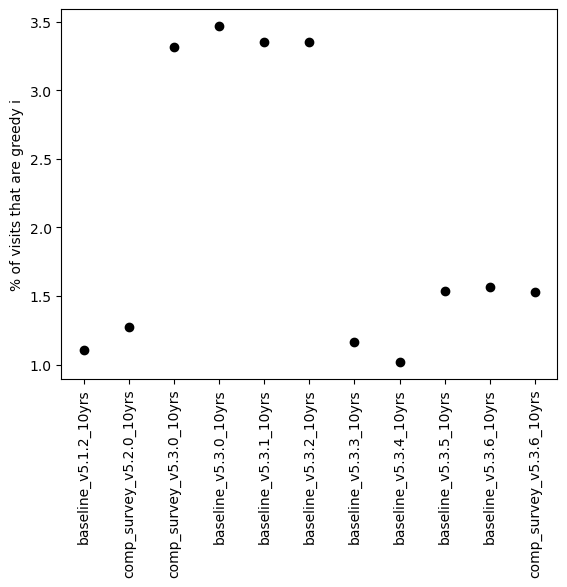

In [65]:
fig, ax = plt.subplots()
ax.plot(data_loaded.loc[times]["Identity Percents_greedy i UniSlicer"], 'ko')
label_add = ''
ax.set_ylabel("% of visits that are greedy i")
ax.tick_params(axis='x', labelrotation = 90)



